# Dataset Analysis

This notebook covers **EDA** (one clear section per dataset) and **post-training diagnostics** (predicted vs actual, residuals, feature importance).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.analysis.dataset_report import print_basic_info, print_missing_values, print_target_summary
from src.analysis.plots import (
    plot_target_distribution,
    plot_numeric_vs_target,
    plot_attendance_by_category,
    plot_attendance_by_year,
    plot_correlation_heatmap,
    plot_predicted_vs_actual,
    plot_residuals,
    plot_feature_importance,
)
from src.modeling.models import get_regression_models
from src.modeling.metrics import calculate_regression_metrics

In [2]:
DATASETS = {
    "v1_baseline":        "E:\\code\\tour-prediction\\data\\processed\\attendance_v1_baseline.csv",
    "v2_artist":          "E:\\code\\tour-prediction\\data\\processed\\attendance_v2_artist.csv",
    "v3_artist_geo":      "E:\\code\\tour-prediction\\data\\processed\\attendance_v3_artist_geo.csv",
    "v4_artist_geo_time": "E:\\code\\tour-prediction\\data\\processed\\attendance_v4_artist_geo_time.csv",
    "v5_full":            "E:\\code\\tour-prediction\\data\\processed\\attendance_v5_full.csv",
    "v6_no_artist":       "E:\\code\\tour-prediction\\data\\processed\\attendance_v6_no_artist.csv",
}

LEAKY_COLS = ["fill_rate", "box_score", "avg_ticket_price"]
TARGET = "attendance"

# Categorical columns to plot boxplots for (only plotted when present in dataset)
CAT_COLS = ["artist_name", "country", "venue_type"]

## Part 1 — Exploratory Data Analysis

One section per dataset. Each section covers:
1. Basic info + missing values + target summary
2. Target distribution (linear and log scale)
3. Numeric features vs target (scatter)
4. Categorical features vs target (box plots)
5. Attendance over time (when `show_year` is present)
6. Correlation heatmap


######################################################################
#  DATASET: v1_baseline
######################################################################

── 1. Basic info ─────────────────────────────────────────────────────

DATASET: v1_baseline
Shape: 1169 rows × 9 columns

Columns (9):
  - attendance: float64
  - reporting_status: str
  - venue_name: str
  - venue_type: str
  - venue_capacity: float64
  - continent: str
  - country: str
  - city: str
  - show_nights: int64

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   attendance        764 non-null    float64
 1   reporting_status  1169 non-null   str    
 2   venue_name        1165 non-null   str    
 3   venue_type        1163 non-null   str    
 4   venue_capacity    1121 non-null   float64
 5   continent         1169 non-null   str    
 6   country     

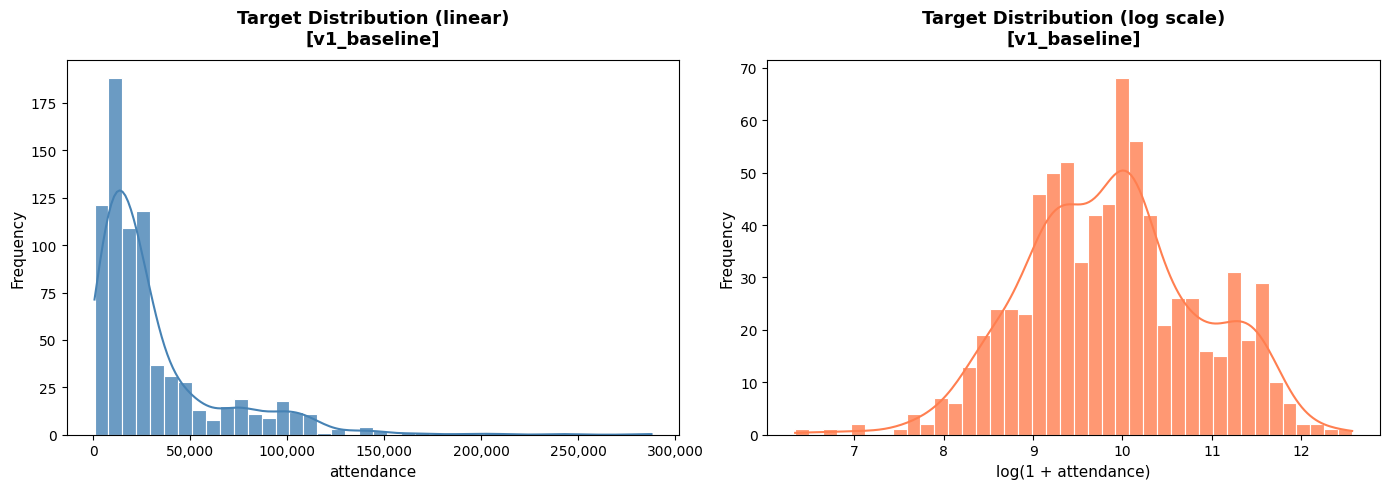


── 3. Numeric features vs target ─────────────────────────────────────


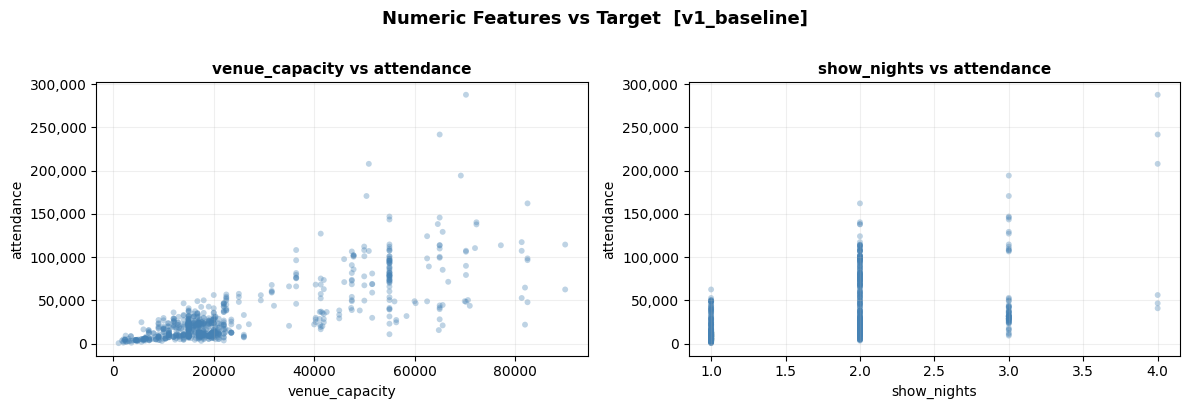


── 4. Categorical features vs target ─────────────────────────────────


e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


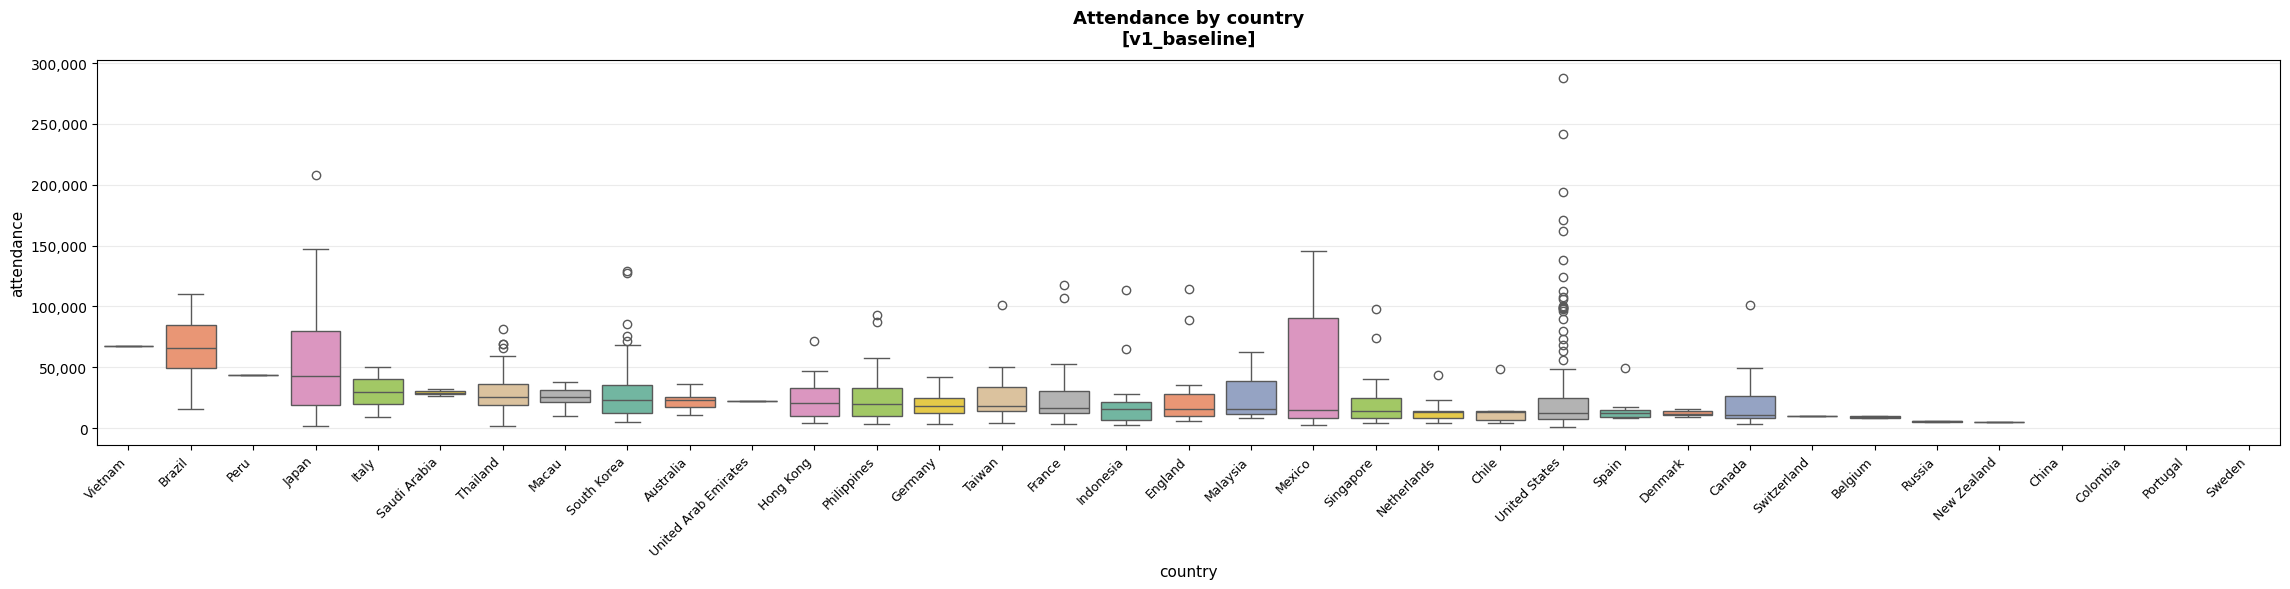

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


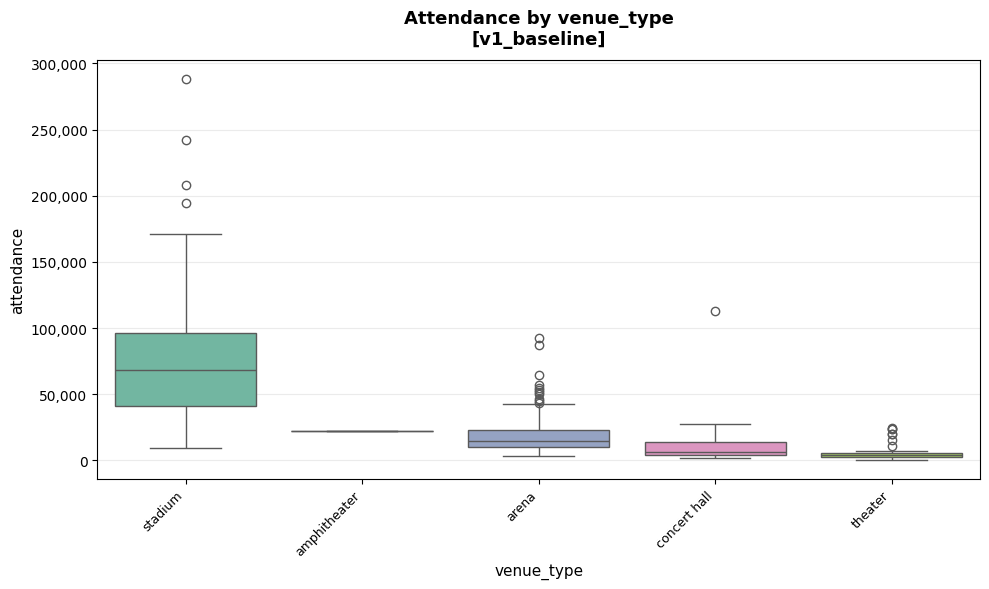


── 5. Attendance over time ───────────────────────────────────────────

── 6. Correlation heatmap ────────────────────────────────────────────


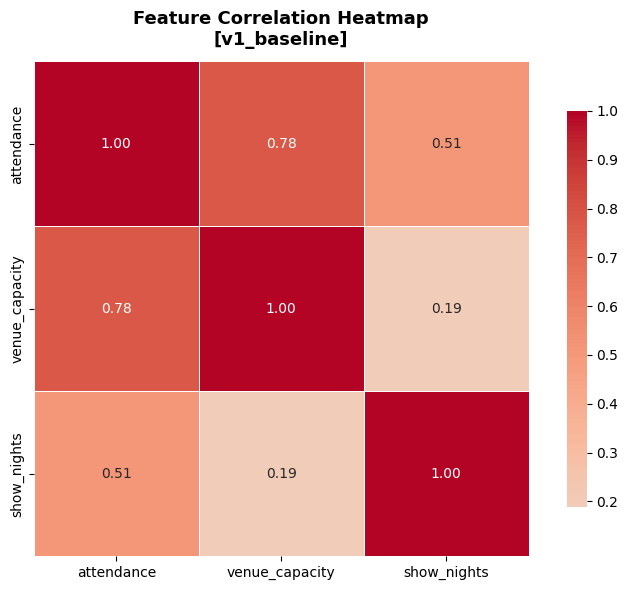


──────────────────────────────────────────────────────────────────────


######################################################################
#  DATASET: v2_artist
######################################################################

── 1. Basic info ─────────────────────────────────────────────────────

DATASET: v2_artist
Shape: 1169 rows × 16 columns

Columns (16):
  - attendance: float64
  - reporting_status: str
  - venue_name: str
  - venue_type: str
  - venue_capacity: float64
  - continent: str
  - country: str
  - city: str
  - show_nights: int64
  - artist_name: str
  - gender: str
  - generation: int64
  - members: int64
  - company: str
  - years_since_debut: int64
  - artist_age_bucket: str

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   attendance         764 non-null    float64
 1   reporting_status   11

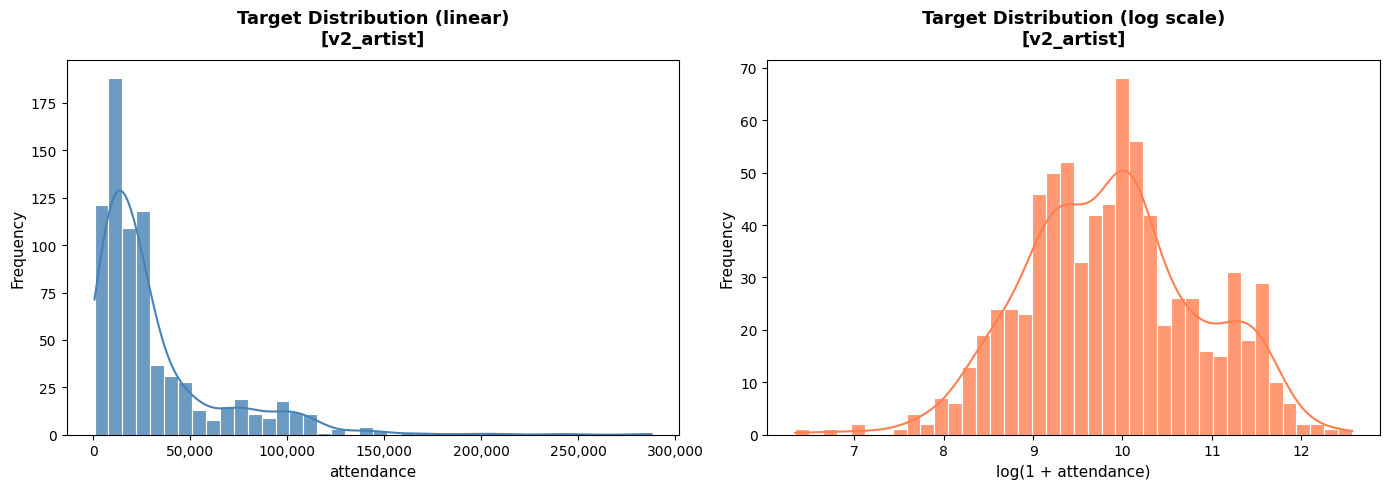


── 3. Numeric features vs target ─────────────────────────────────────


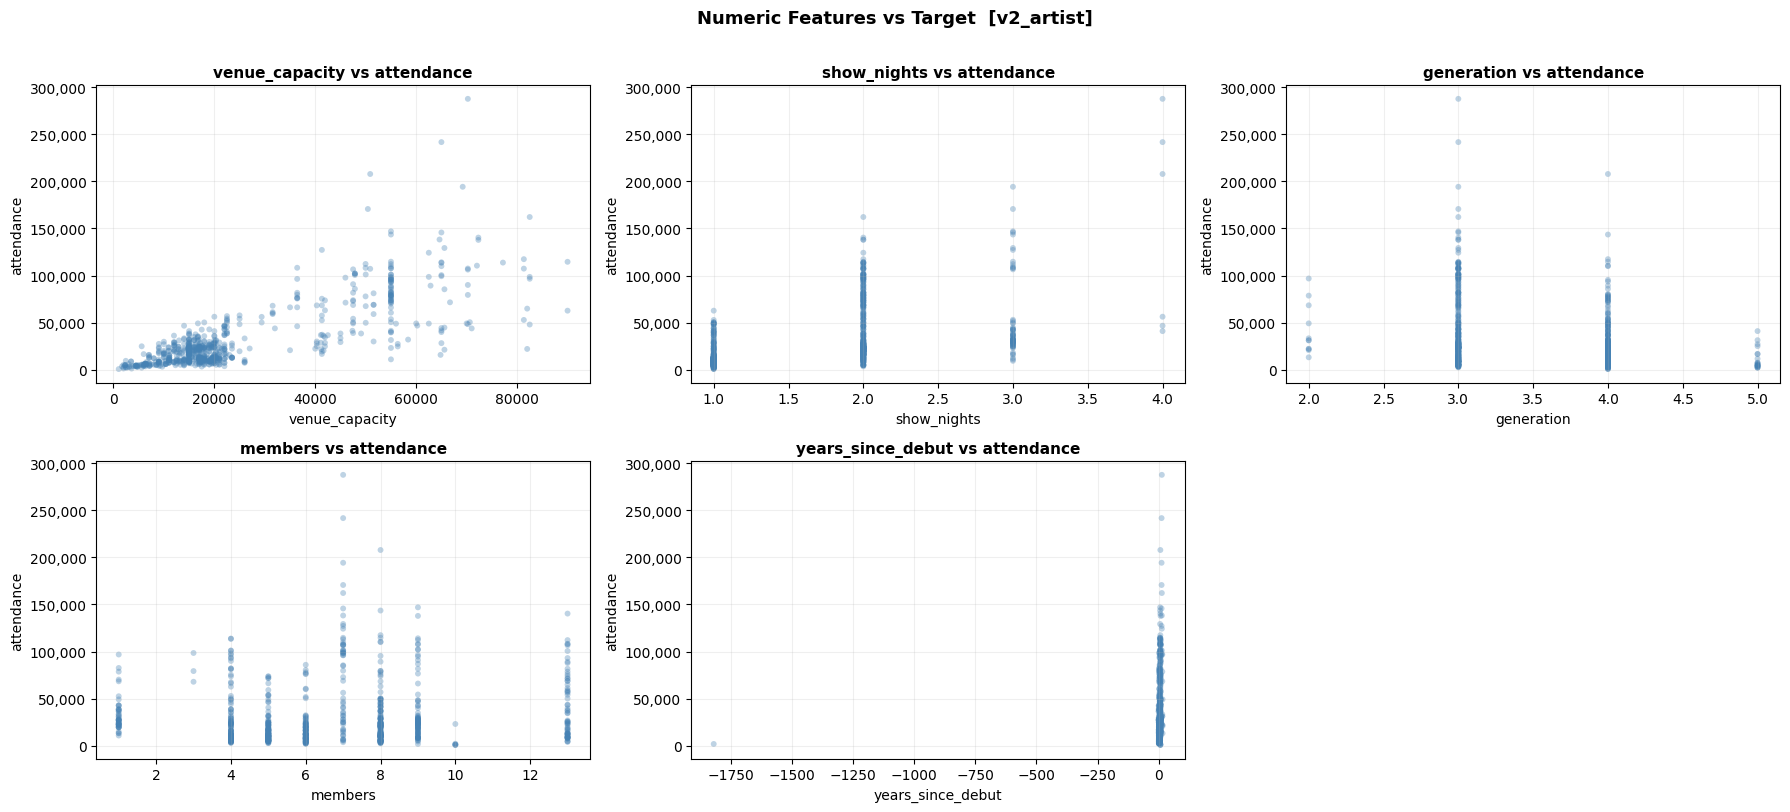


── 4. Categorical features vs target ─────────────────────────────────


e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


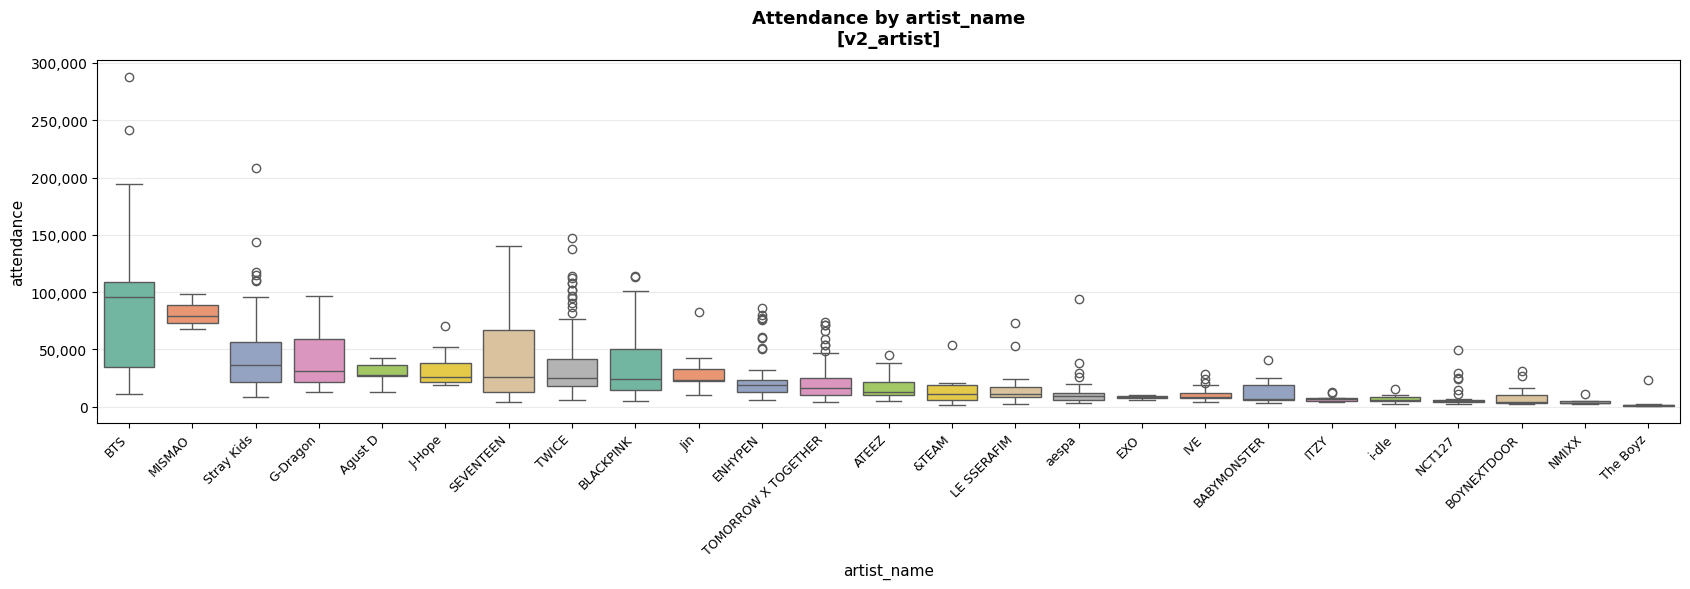

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


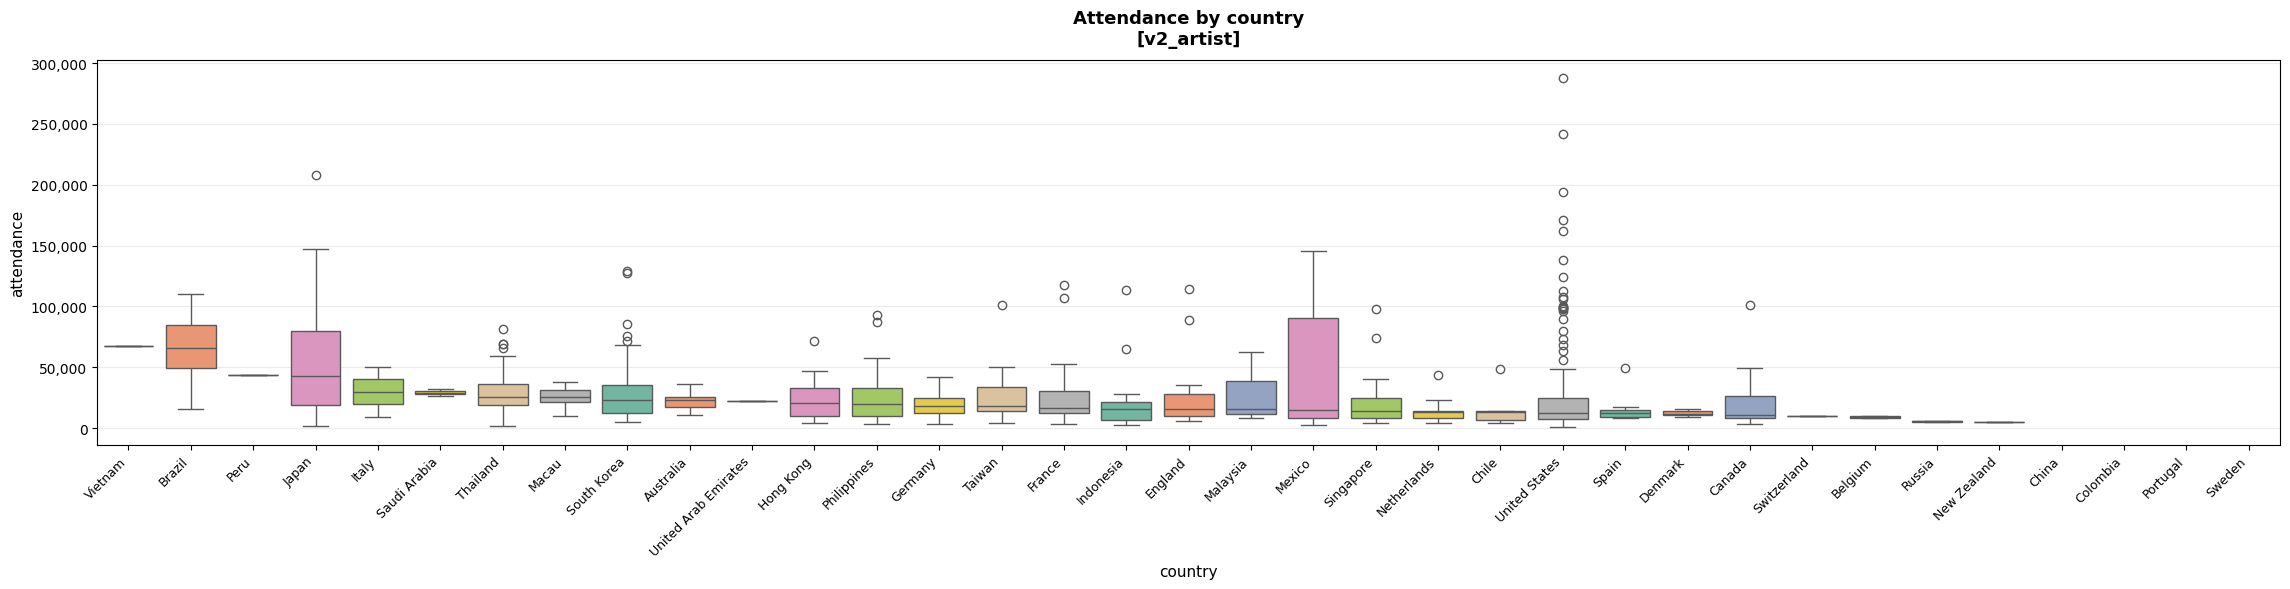

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


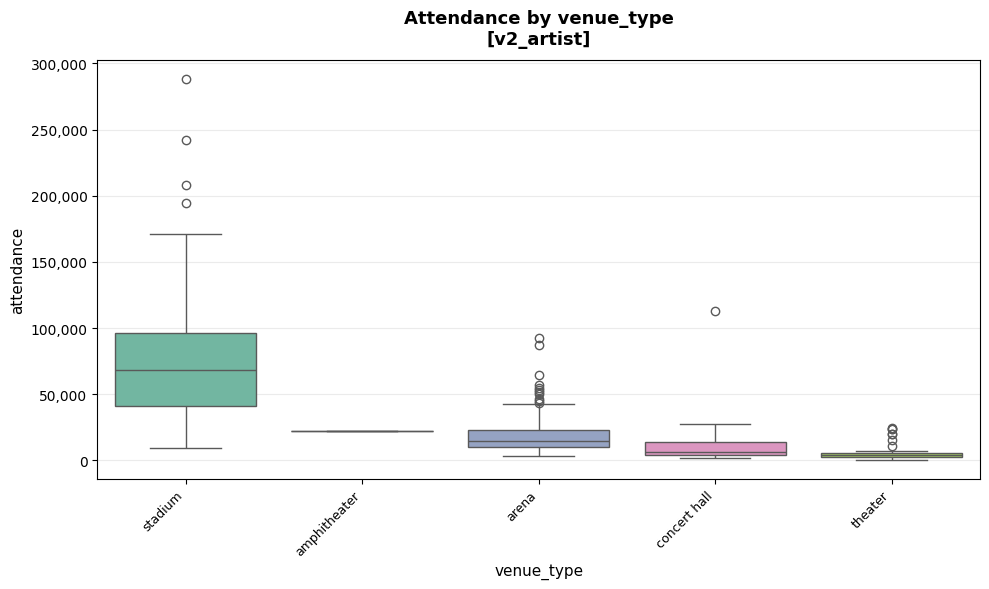


── 5. Attendance over time ───────────────────────────────────────────

── 6. Correlation heatmap ────────────────────────────────────────────


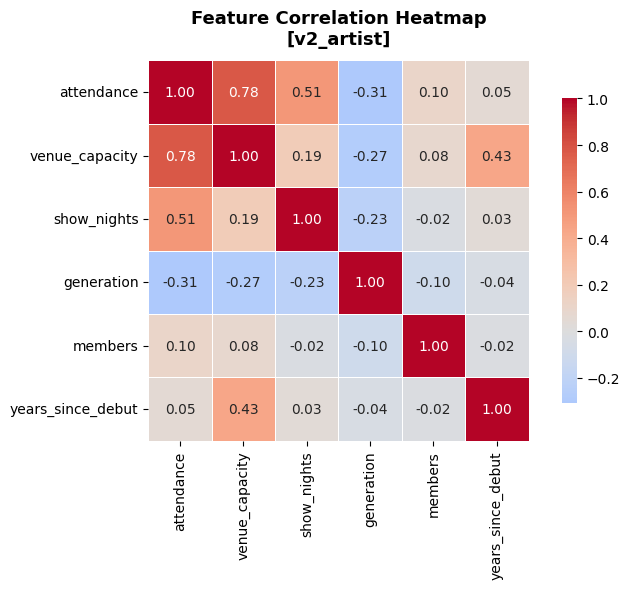


──────────────────────────────────────────────────────────────────────


######################################################################
#  DATASET: v3_artist_geo
######################################################################

── 1. Basic info ─────────────────────────────────────────────────────

DATASET: v3_artist_geo
Shape: 1169 rows × 17 columns

Columns (17):
  - attendance: float64
  - reporting_status: str
  - venue_name: str
  - venue_type: str
  - venue_capacity: float64
  - continent: str
  - country: str
  - city: str
  - show_nights: int64
  - artist_name: str
  - gender: str
  - generation: int64
  - members: int64
  - company: str
  - years_since_debut: int64
  - artist_age_bucket: str
  - artist_country: str

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   attendance         764 non-null    fl

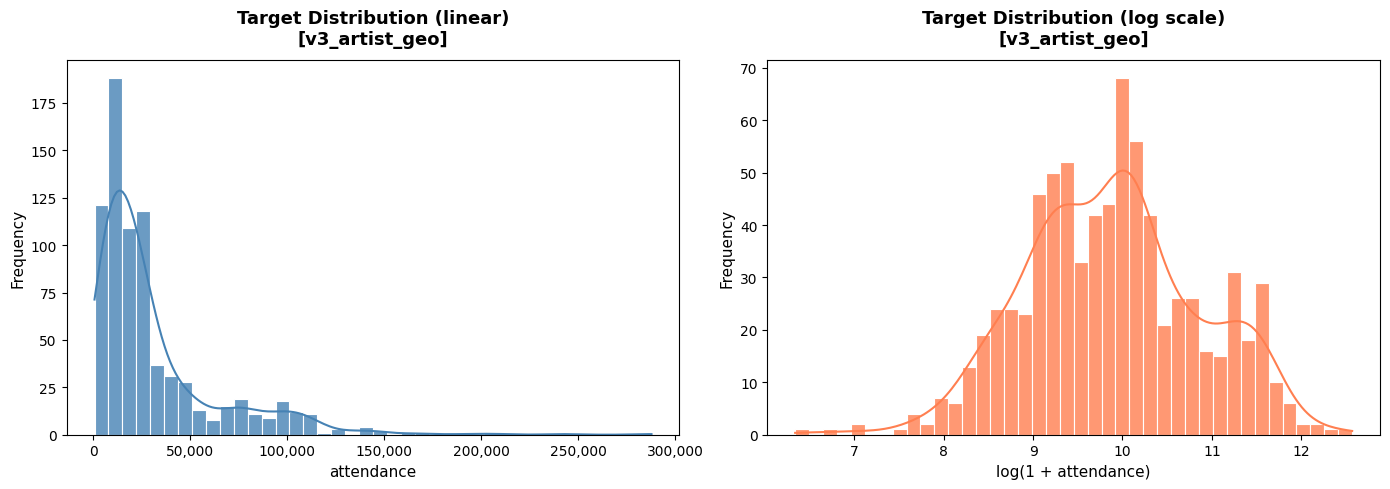


── 3. Numeric features vs target ─────────────────────────────────────


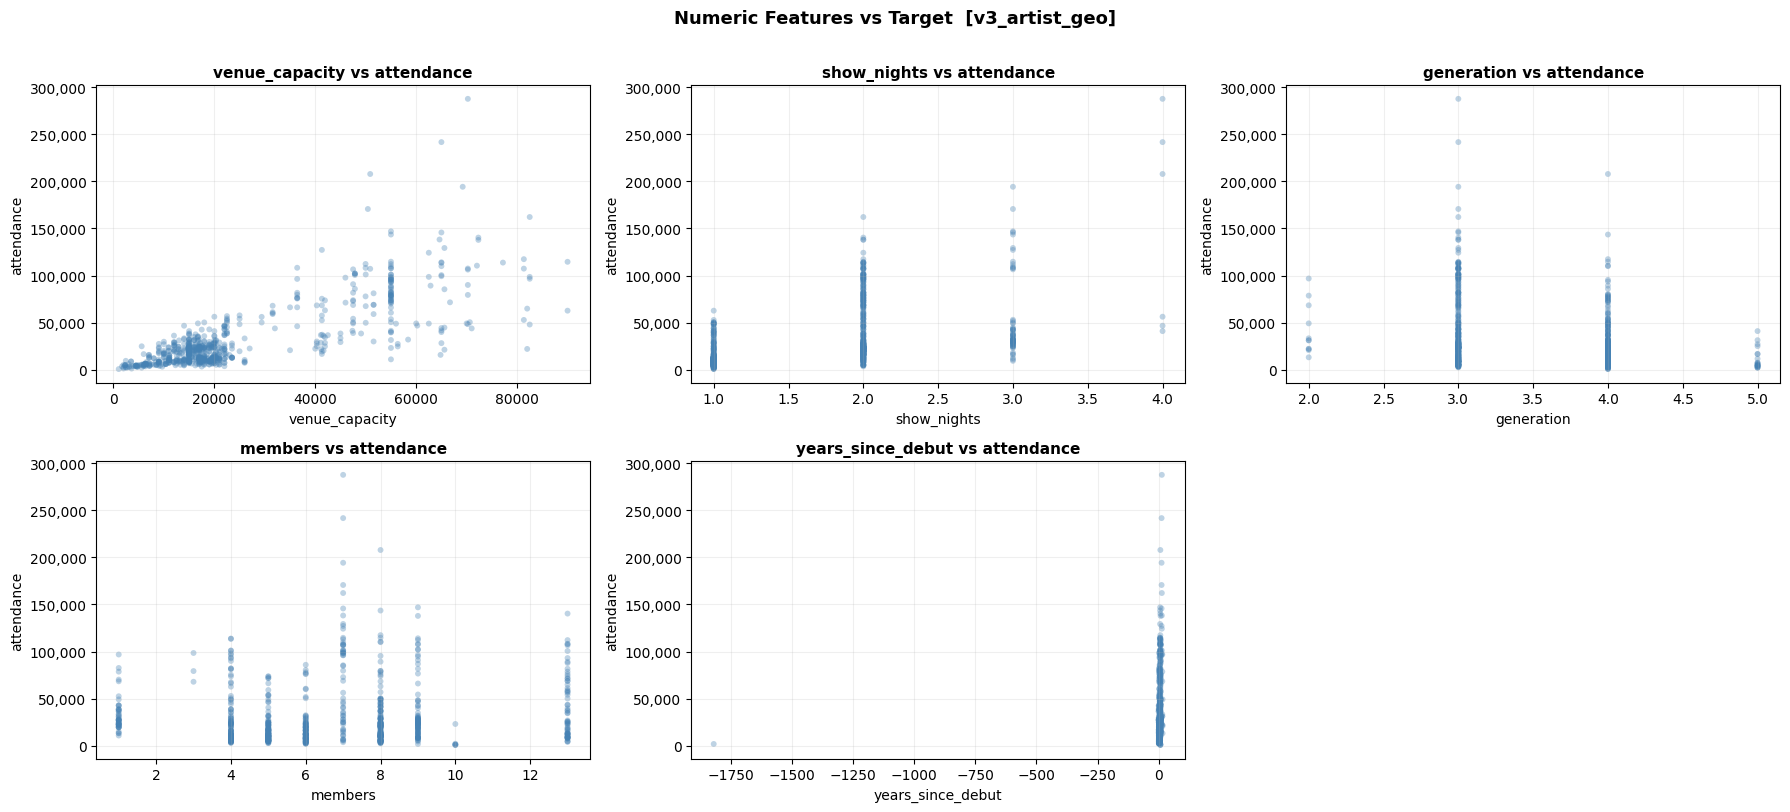


── 4. Categorical features vs target ─────────────────────────────────


e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


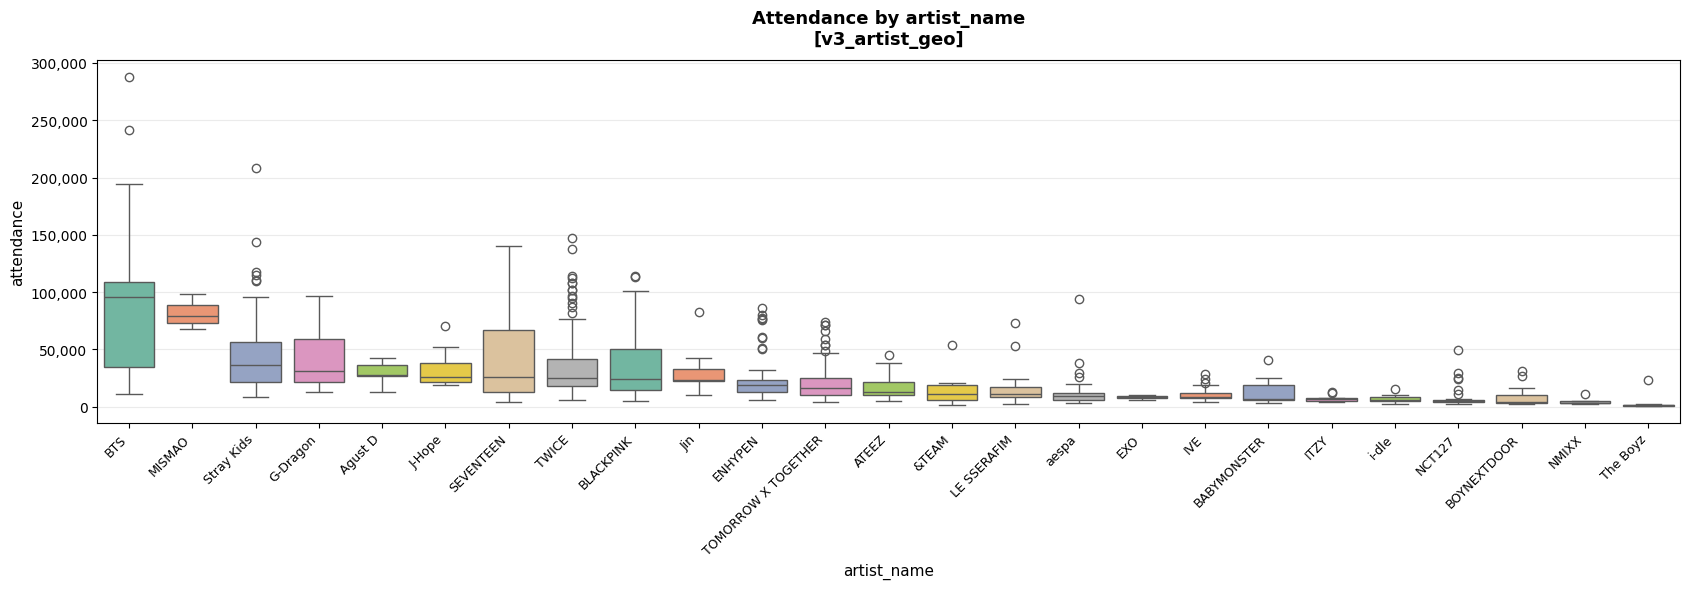

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


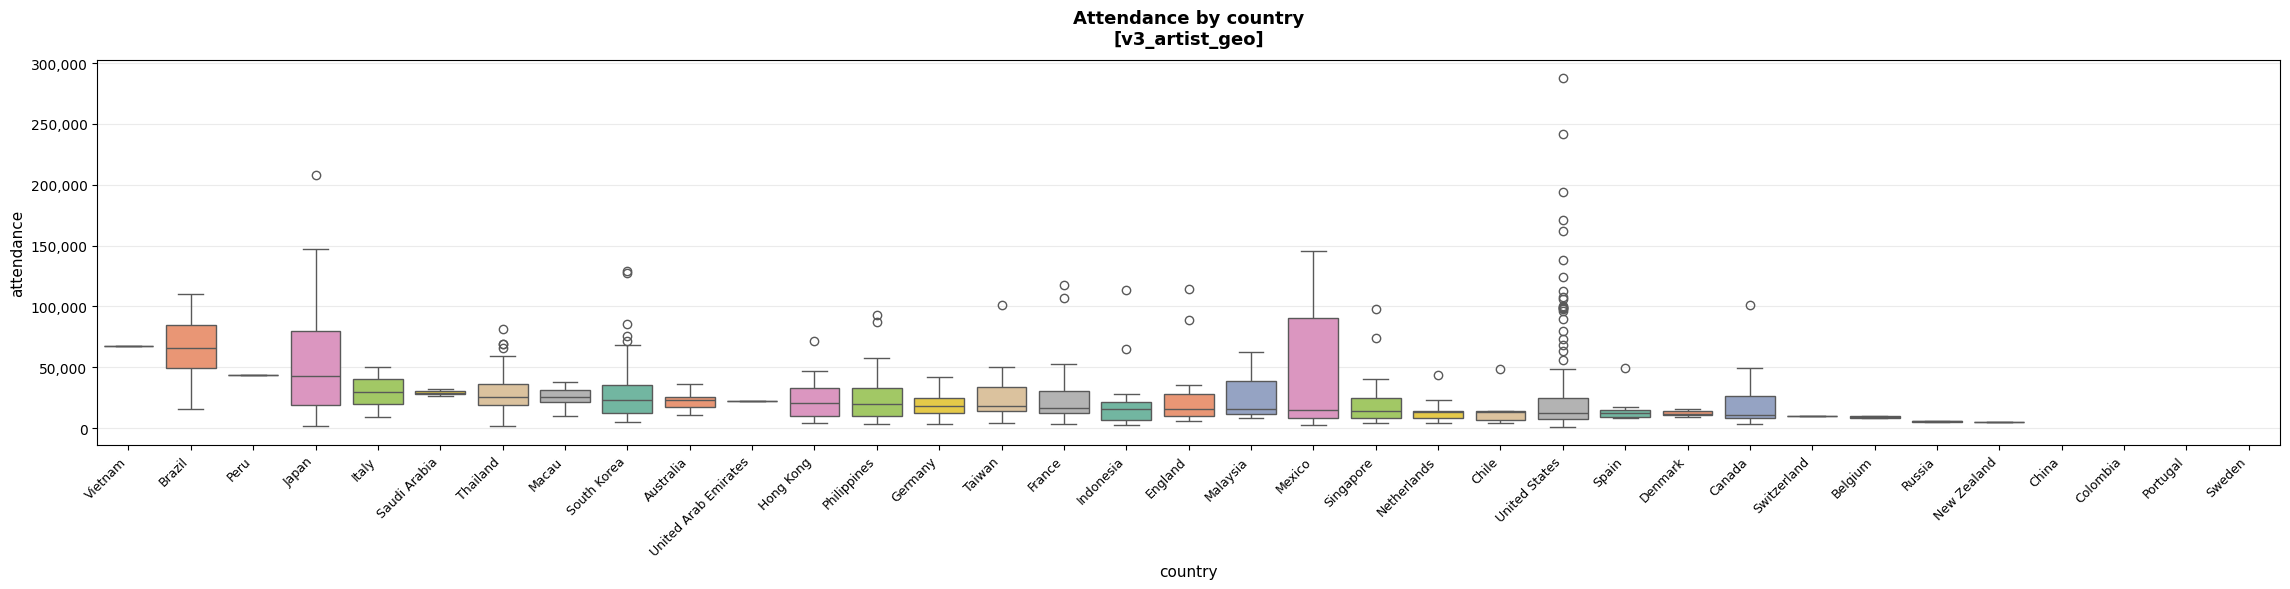

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


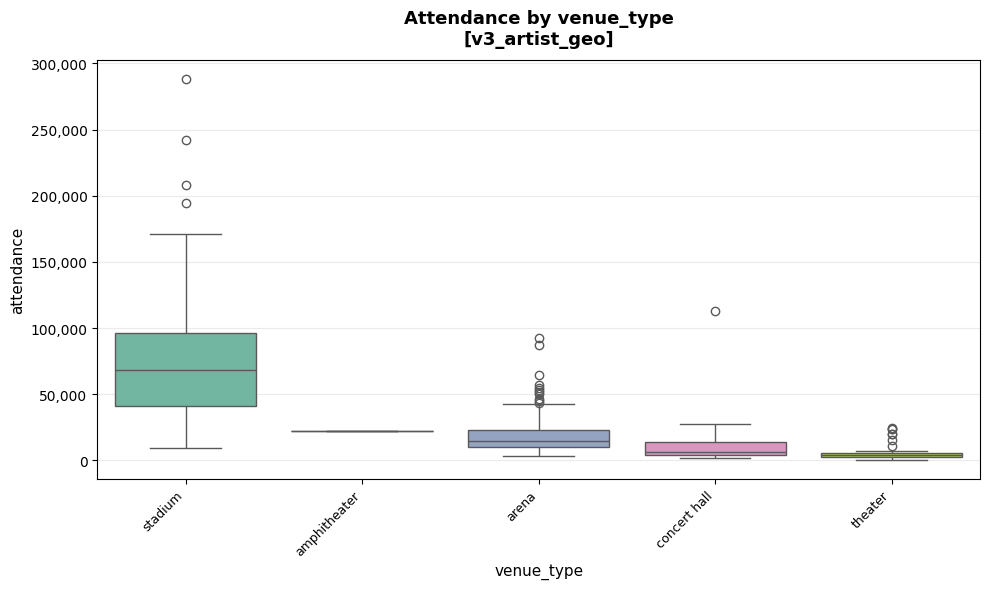


── 5. Attendance over time ───────────────────────────────────────────

── 6. Correlation heatmap ────────────────────────────────────────────


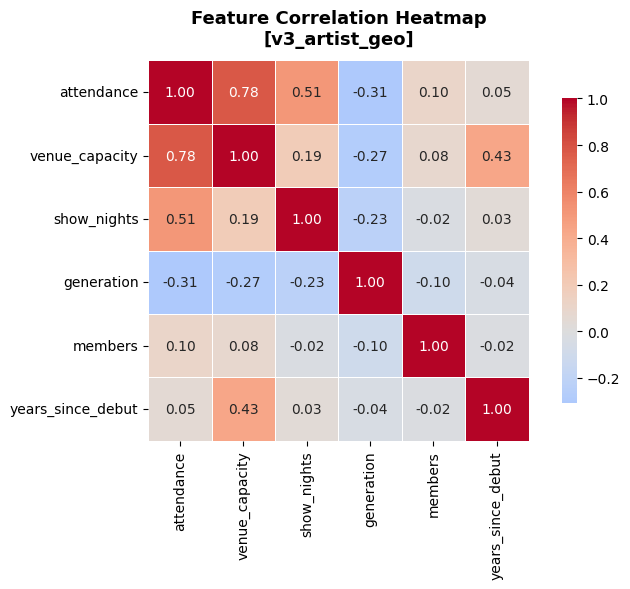


──────────────────────────────────────────────────────────────────────


######################################################################
#  DATASET: v4_artist_geo_time
######################################################################

── 1. Basic info ─────────────────────────────────────────────────────

DATASET: v4_artist_geo_time
Shape: 1169 rows × 23 columns

Columns (23):
  - attendance: float64
  - reporting_status: str
  - venue_name: str
  - venue_type: str
  - venue_capacity: float64
  - continent: str
  - country: str
  - city: str
  - show_nights: int64
  - artist_name: str
  - gender: str
  - generation: int64
  - members: int64
  - company: str
  - years_since_debut: int64
  - artist_age_bucket: str
  - artist_country: str
  - show_year: int64
  - show_month: int64
  - show_quarter: int64
  - weekday_1: str
  - weekday_n: str
  - is_weekend: int64

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 23 columns):
 

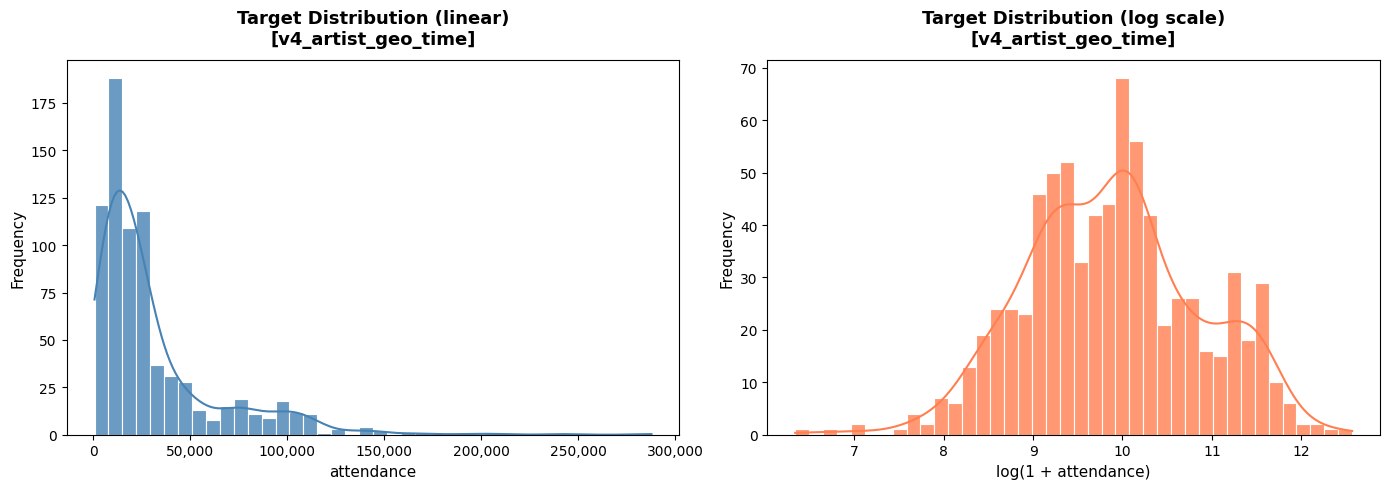


── 3. Numeric features vs target ─────────────────────────────────────


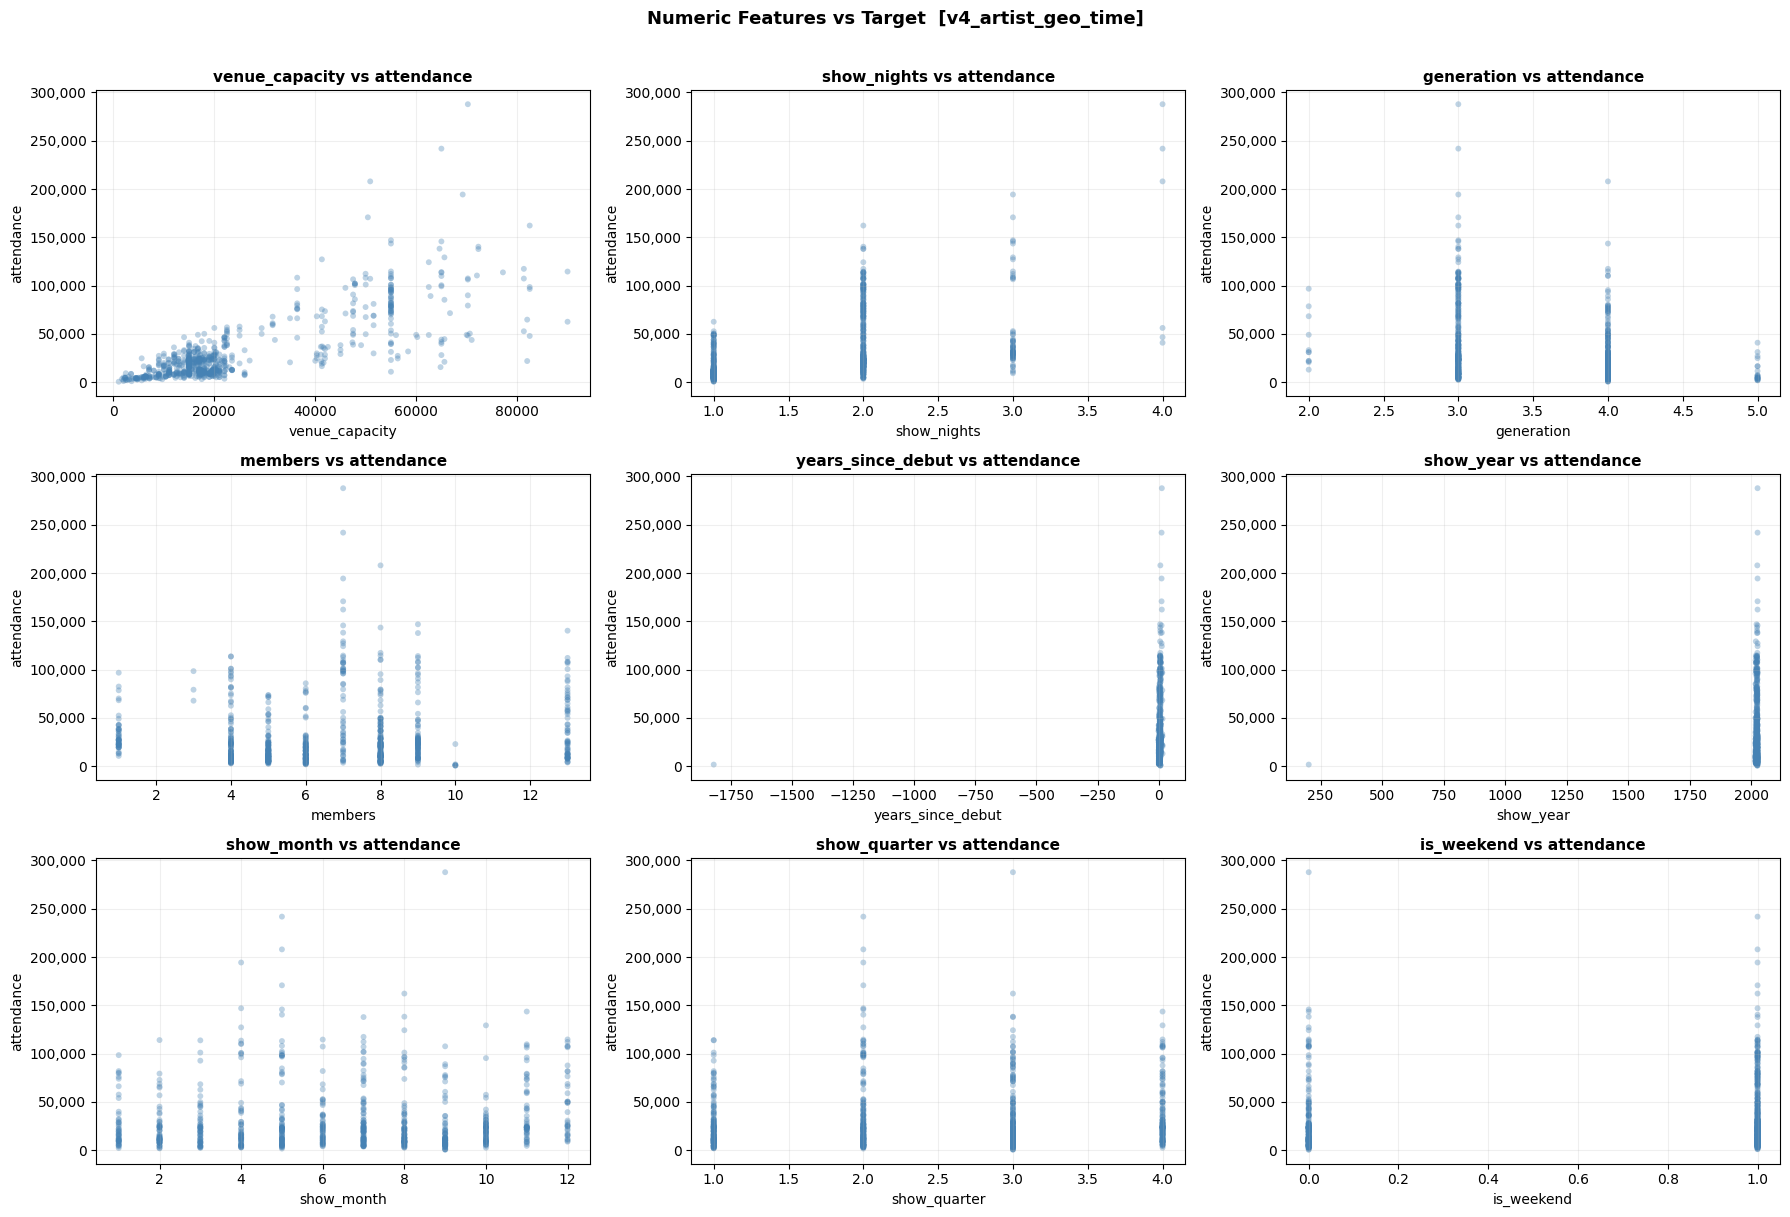


── 4. Categorical features vs target ─────────────────────────────────


e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


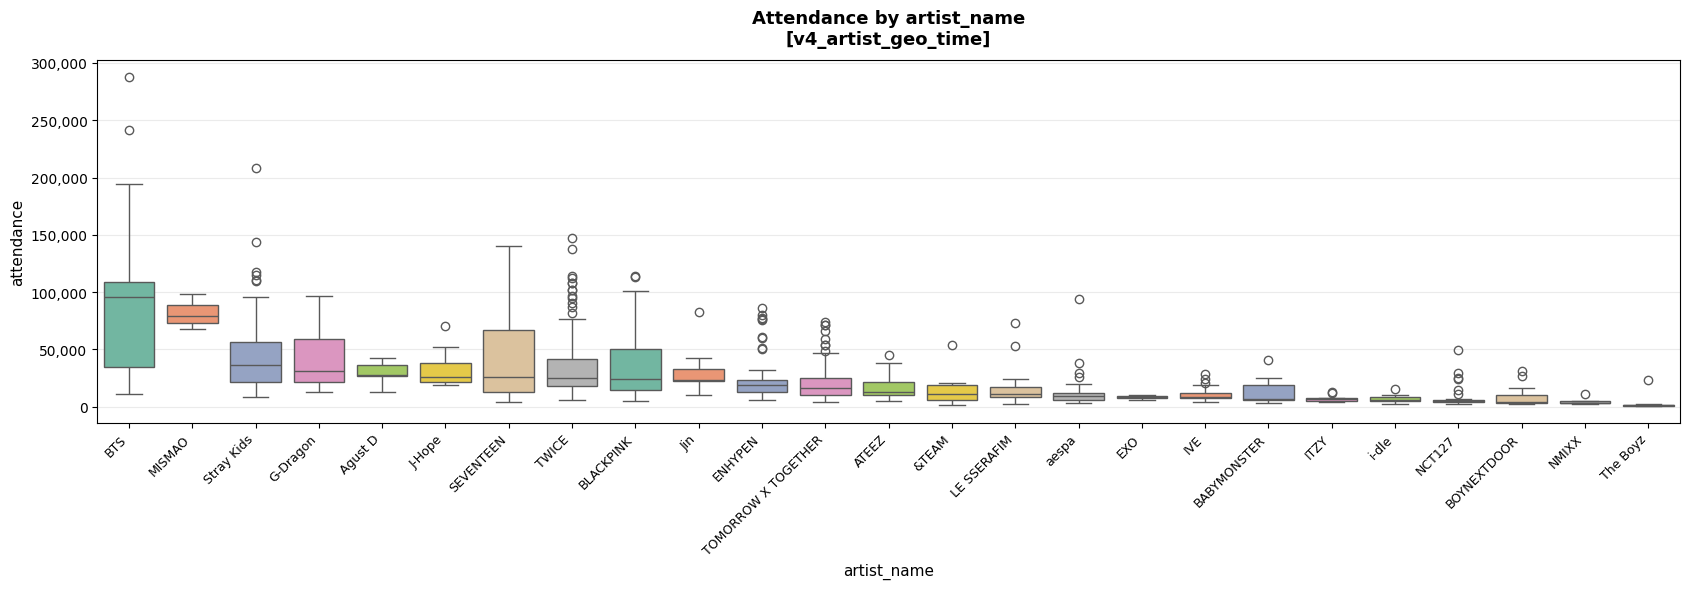

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


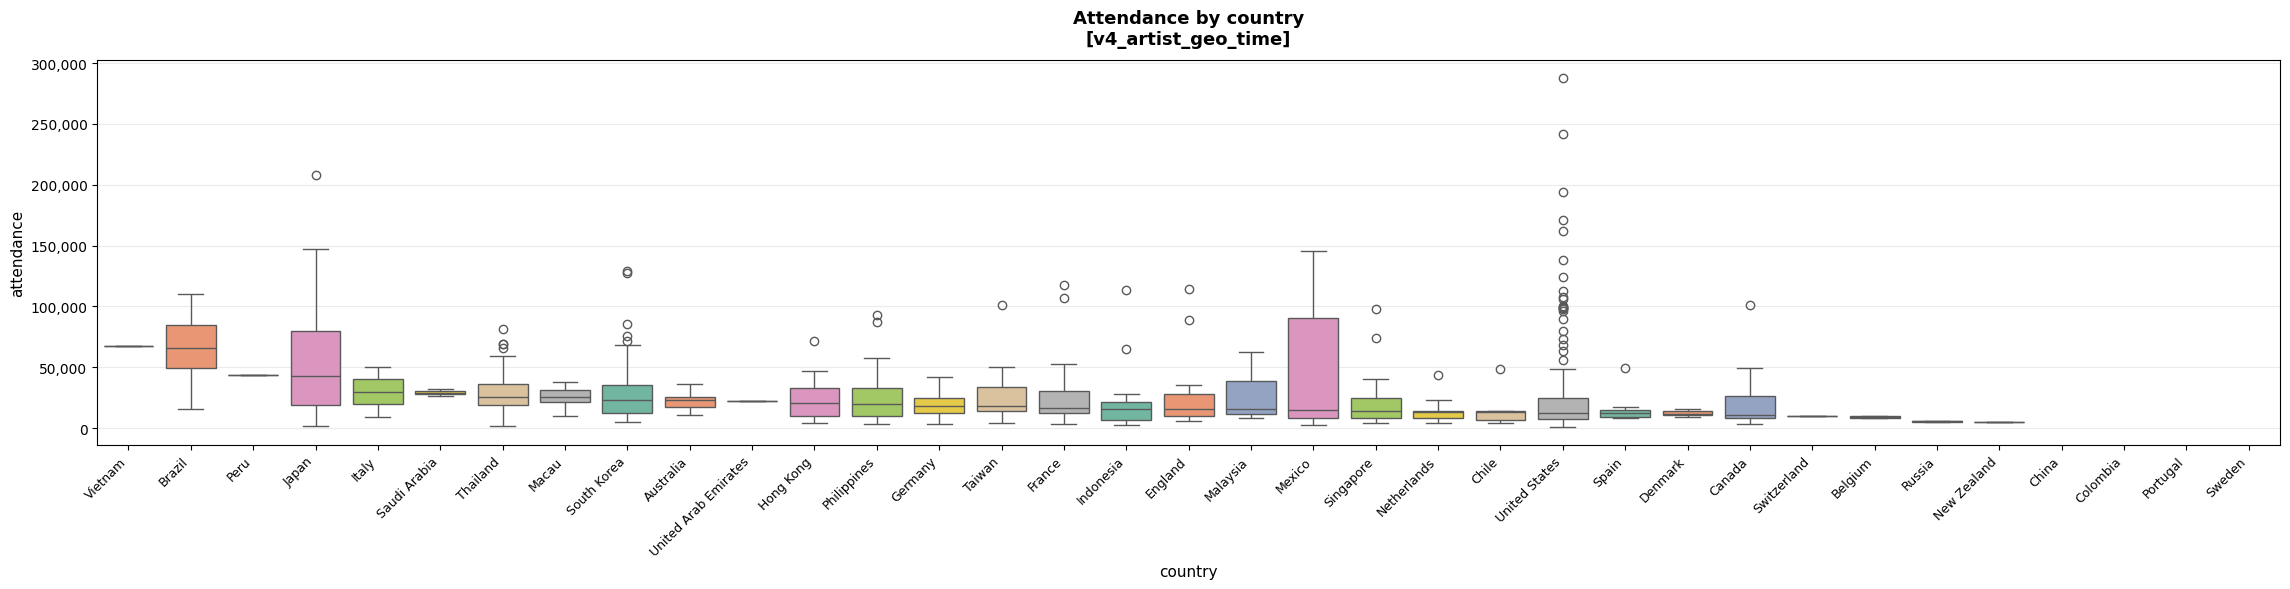

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


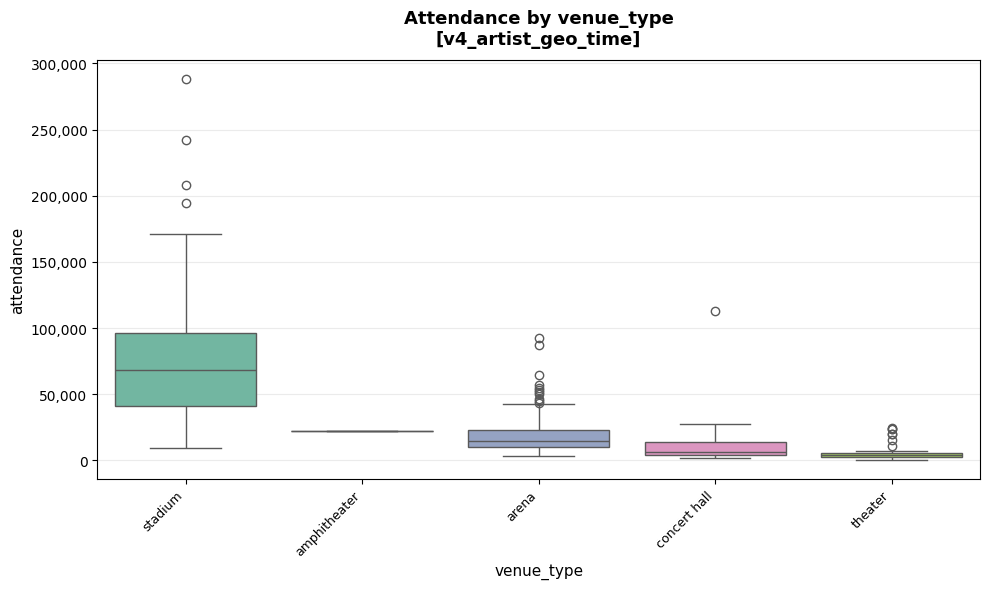


── 5. Attendance over time ───────────────────────────────────────────


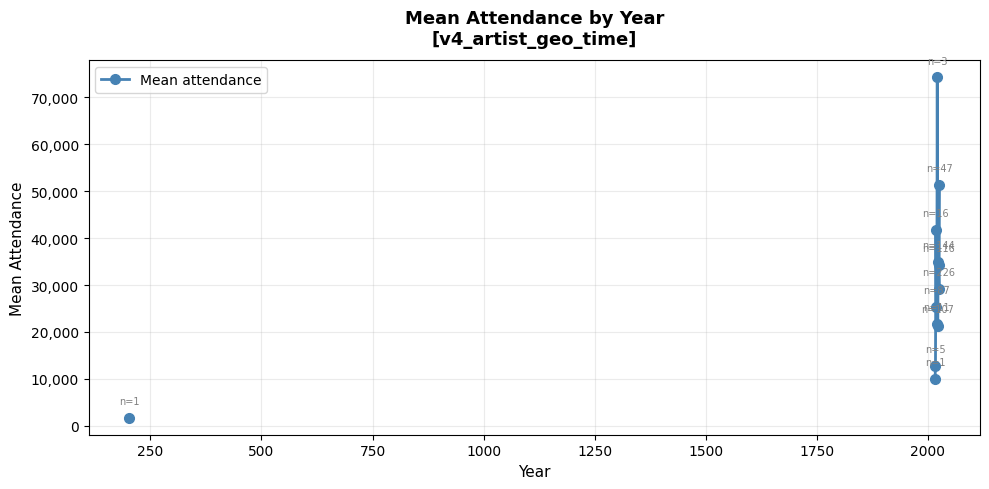


── 6. Correlation heatmap ────────────────────────────────────────────


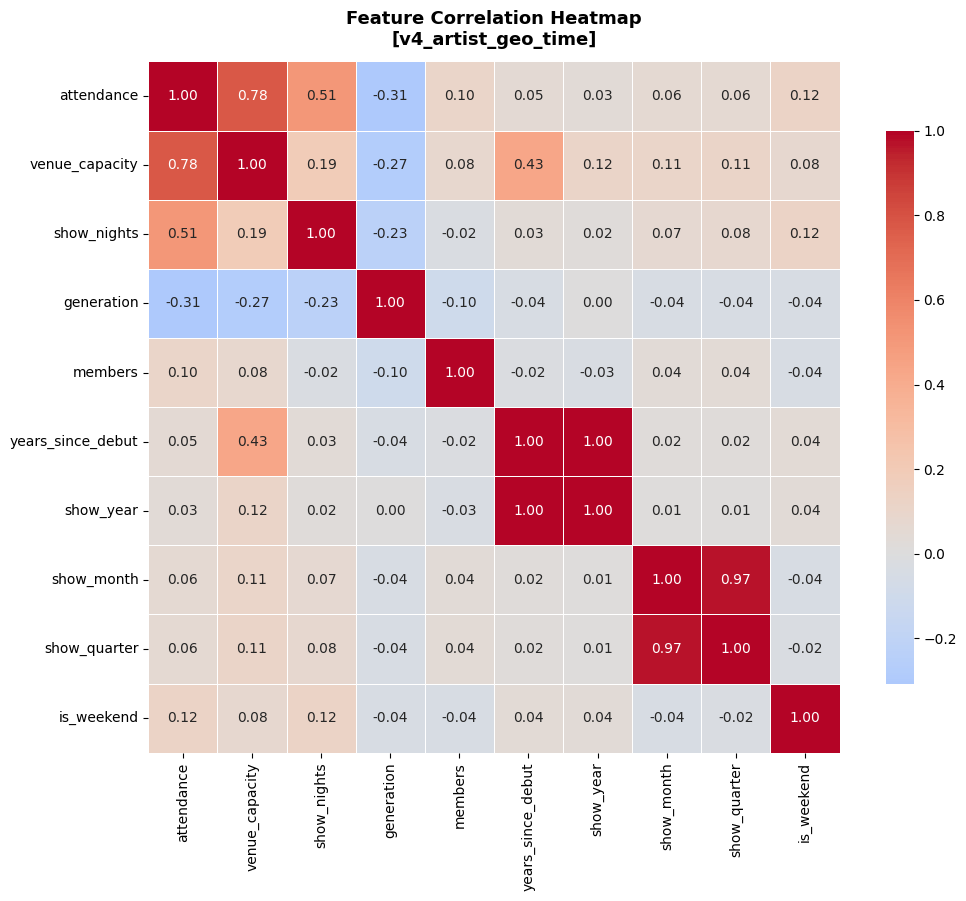


──────────────────────────────────────────────────────────────────────


######################################################################
#  DATASET: v5_full
######################################################################

── 1. Basic info ─────────────────────────────────────────────────────

DATASET: v5_full
Shape: 1169 rows × 24 columns

Columns (24):
  - attendance: float64
  - reporting_status: str
  - artist_name: str
  - gender: str
  - generation: int64
  - tour_type: str
  - members: int64
  - stage_setup: str
  - company: str
  - continent: str
  - country: str
  - city: str
  - venue_name: str
  - venue_type: str
  - venue_capacity: float64
  - show_nights: int64
  - show_year: int64
  - show_month: int64
  - show_quarter: int64
  - weekday_1: str
  - weekday_n: str
  - is_weekend: int64
  - years_since_debut: int64
  - artist_age_bucket: str

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 24 columns):
 #   Co

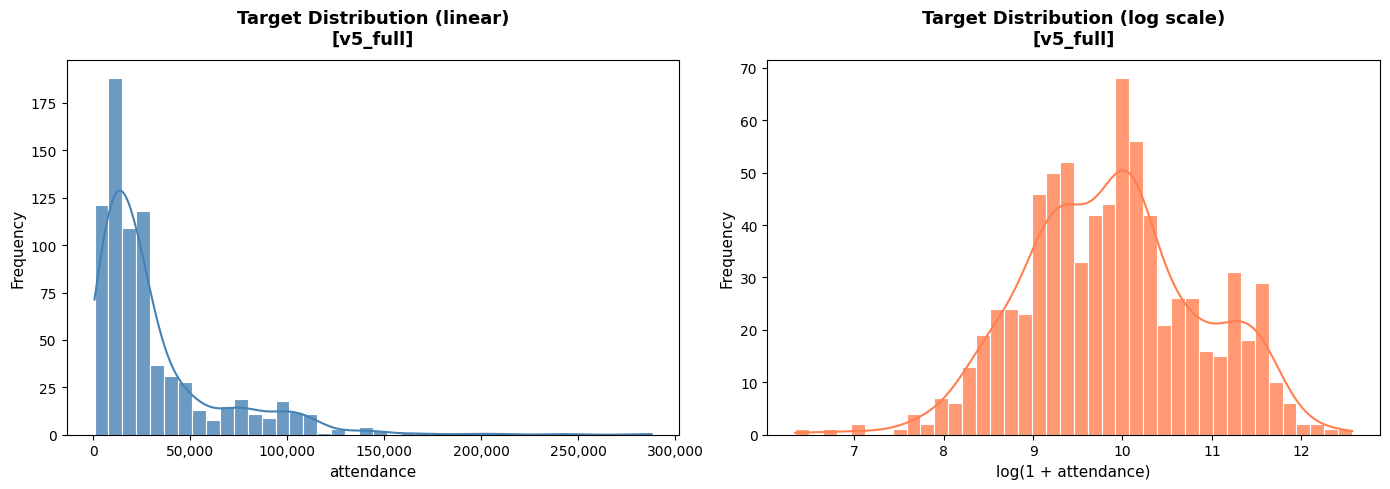


── 3. Numeric features vs target ─────────────────────────────────────


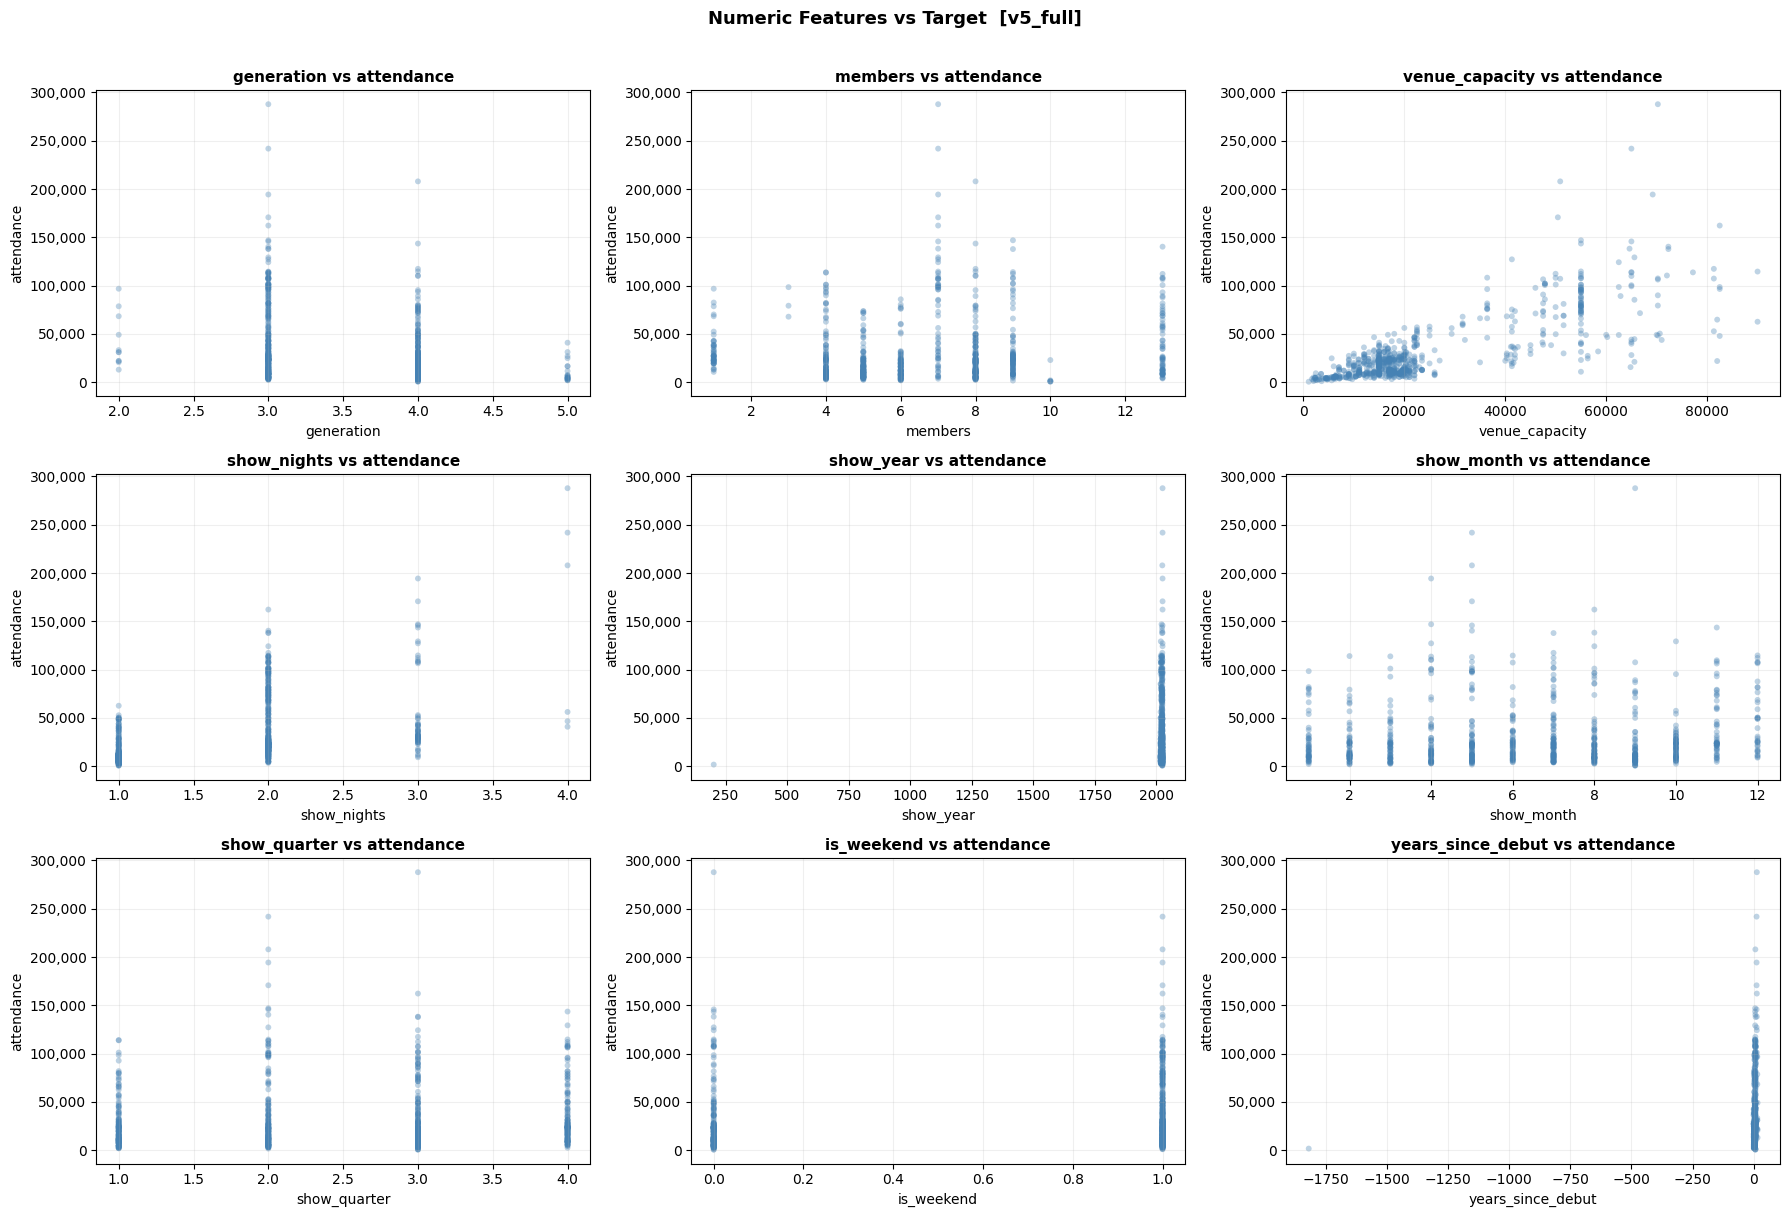


── 4. Categorical features vs target ─────────────────────────────────


e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


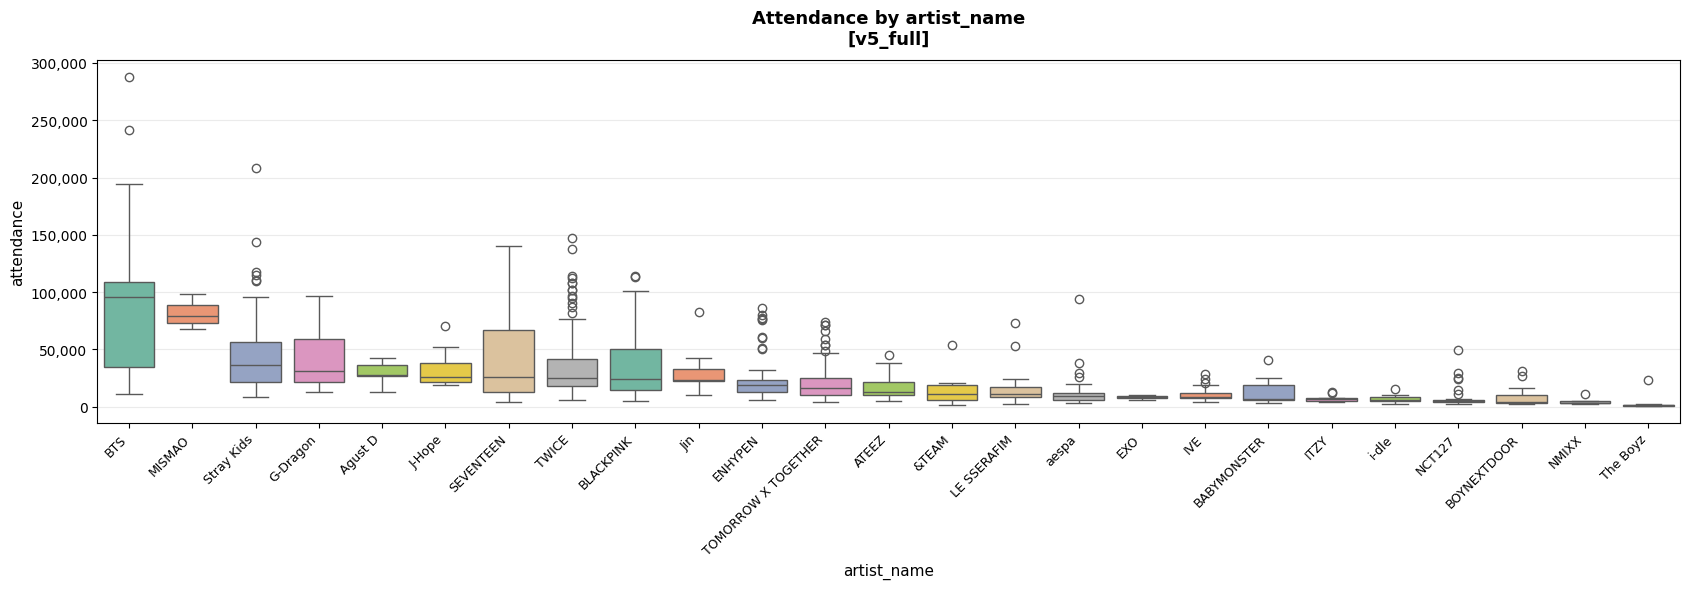

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


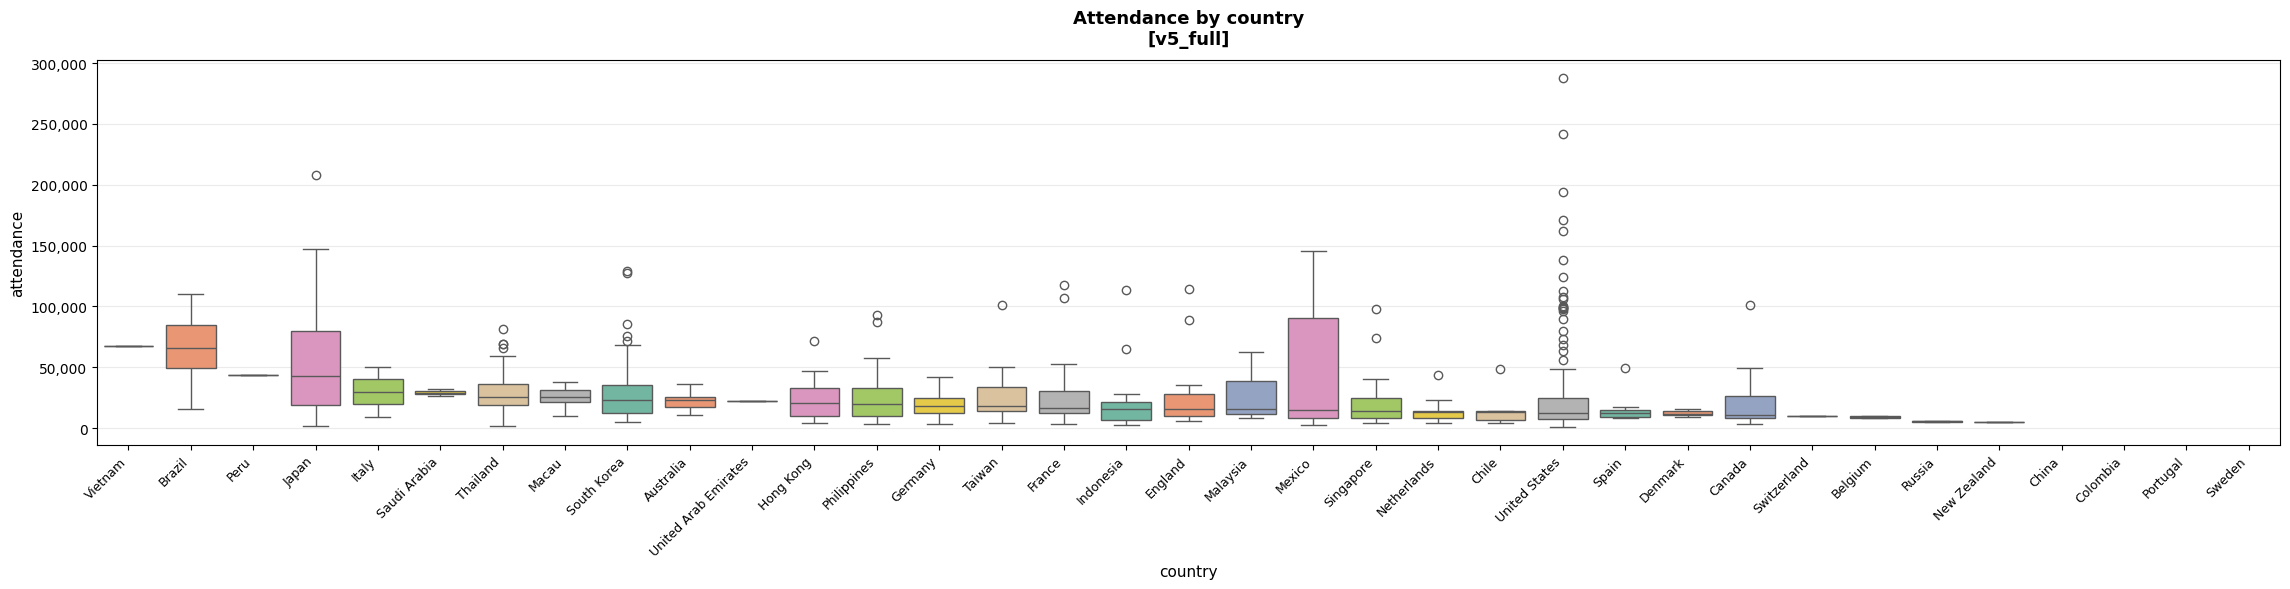

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


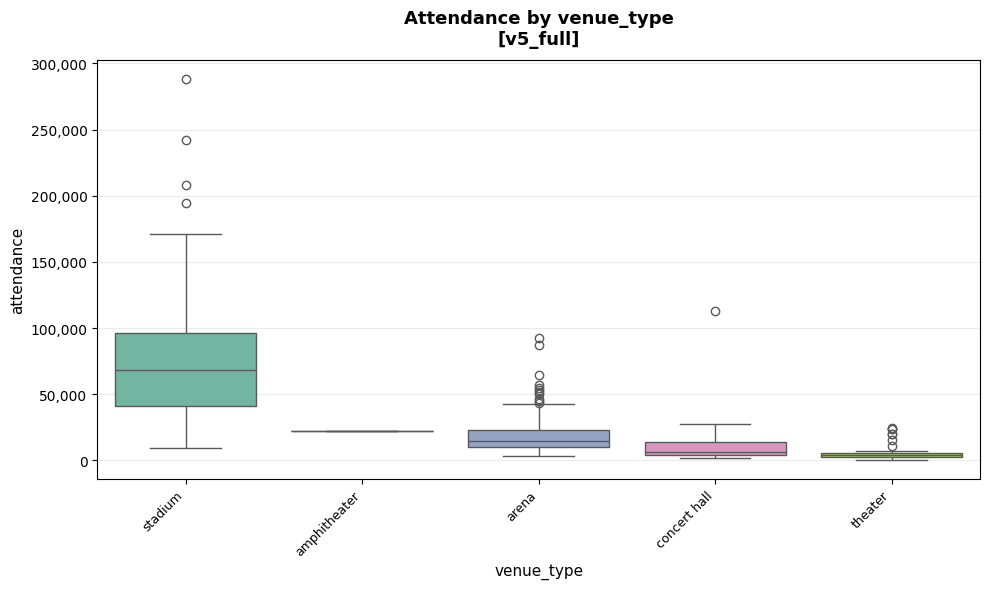


── 5. Attendance over time ───────────────────────────────────────────


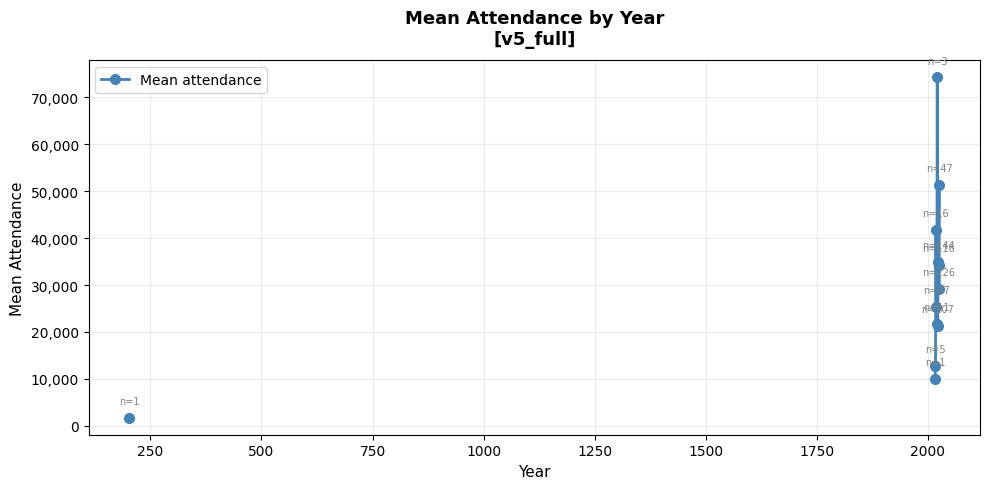


── 6. Correlation heatmap ────────────────────────────────────────────


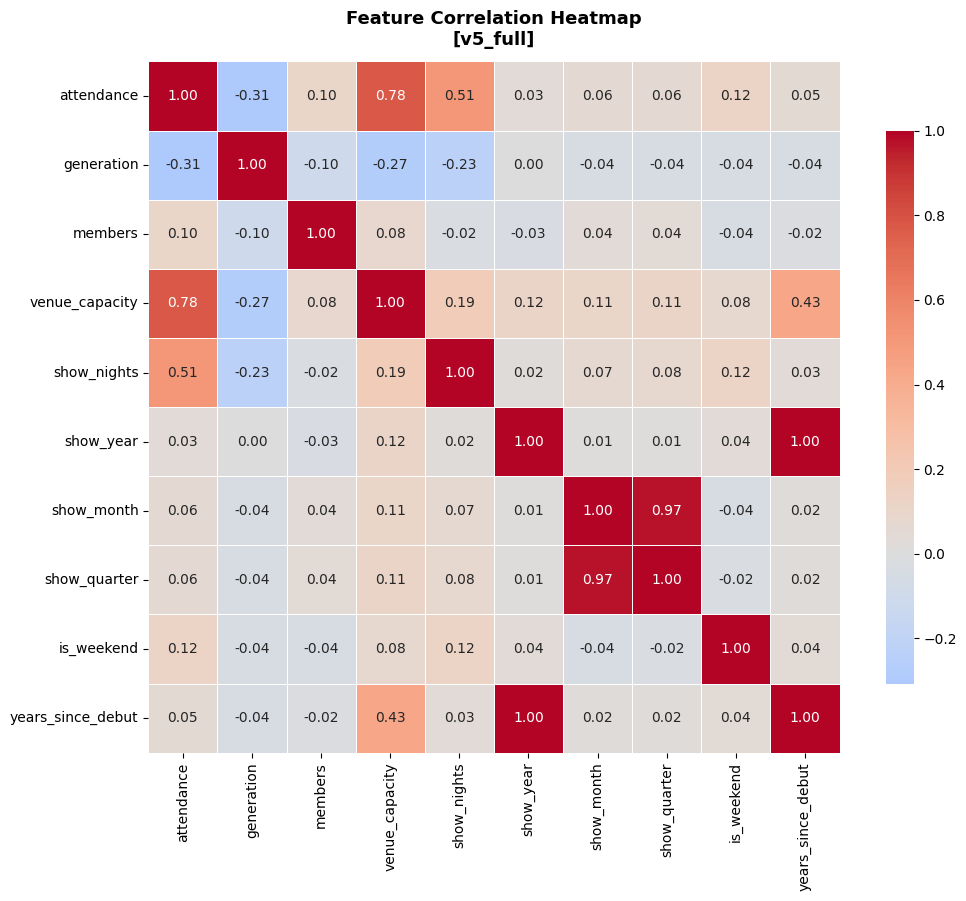


──────────────────────────────────────────────────────────────────────


######################################################################
#  DATASET: v6_no_artist
######################################################################

── 1. Basic info ─────────────────────────────────────────────────────

DATASET: v6_no_artist
Shape: 1169 rows × 22 columns

Columns (22):
  - attendance: float64
  - reporting_status: str
  - gender: str
  - generation: int64
  - tour_type: str
  - members: int64
  - stage_setup: str
  - continent: str
  - country: str
  - city: str
  - venue_name: str
  - venue_type: str
  - venue_capacity: float64
  - show_nights: int64
  - show_year: int64
  - show_month: int64
  - show_quarter: int64
  - weekday_1: str
  - weekday_n: str
  - is_weekend: int64
  - years_since_debut: int64
  - artist_age_bucket: str

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 22 columns):
 #   Column             Non-Null Co

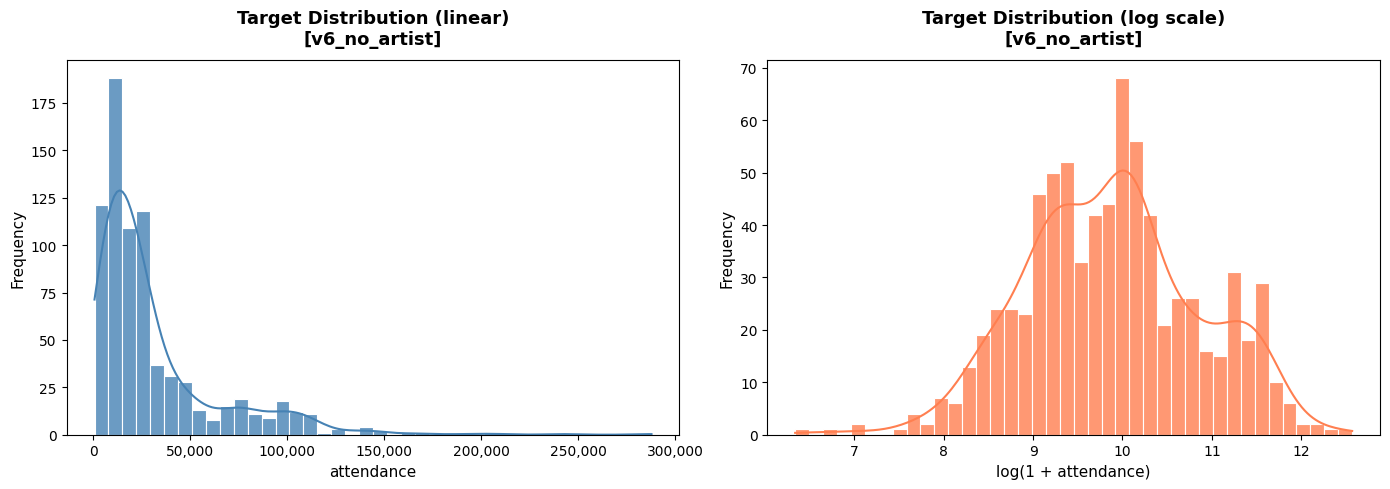


── 3. Numeric features vs target ─────────────────────────────────────


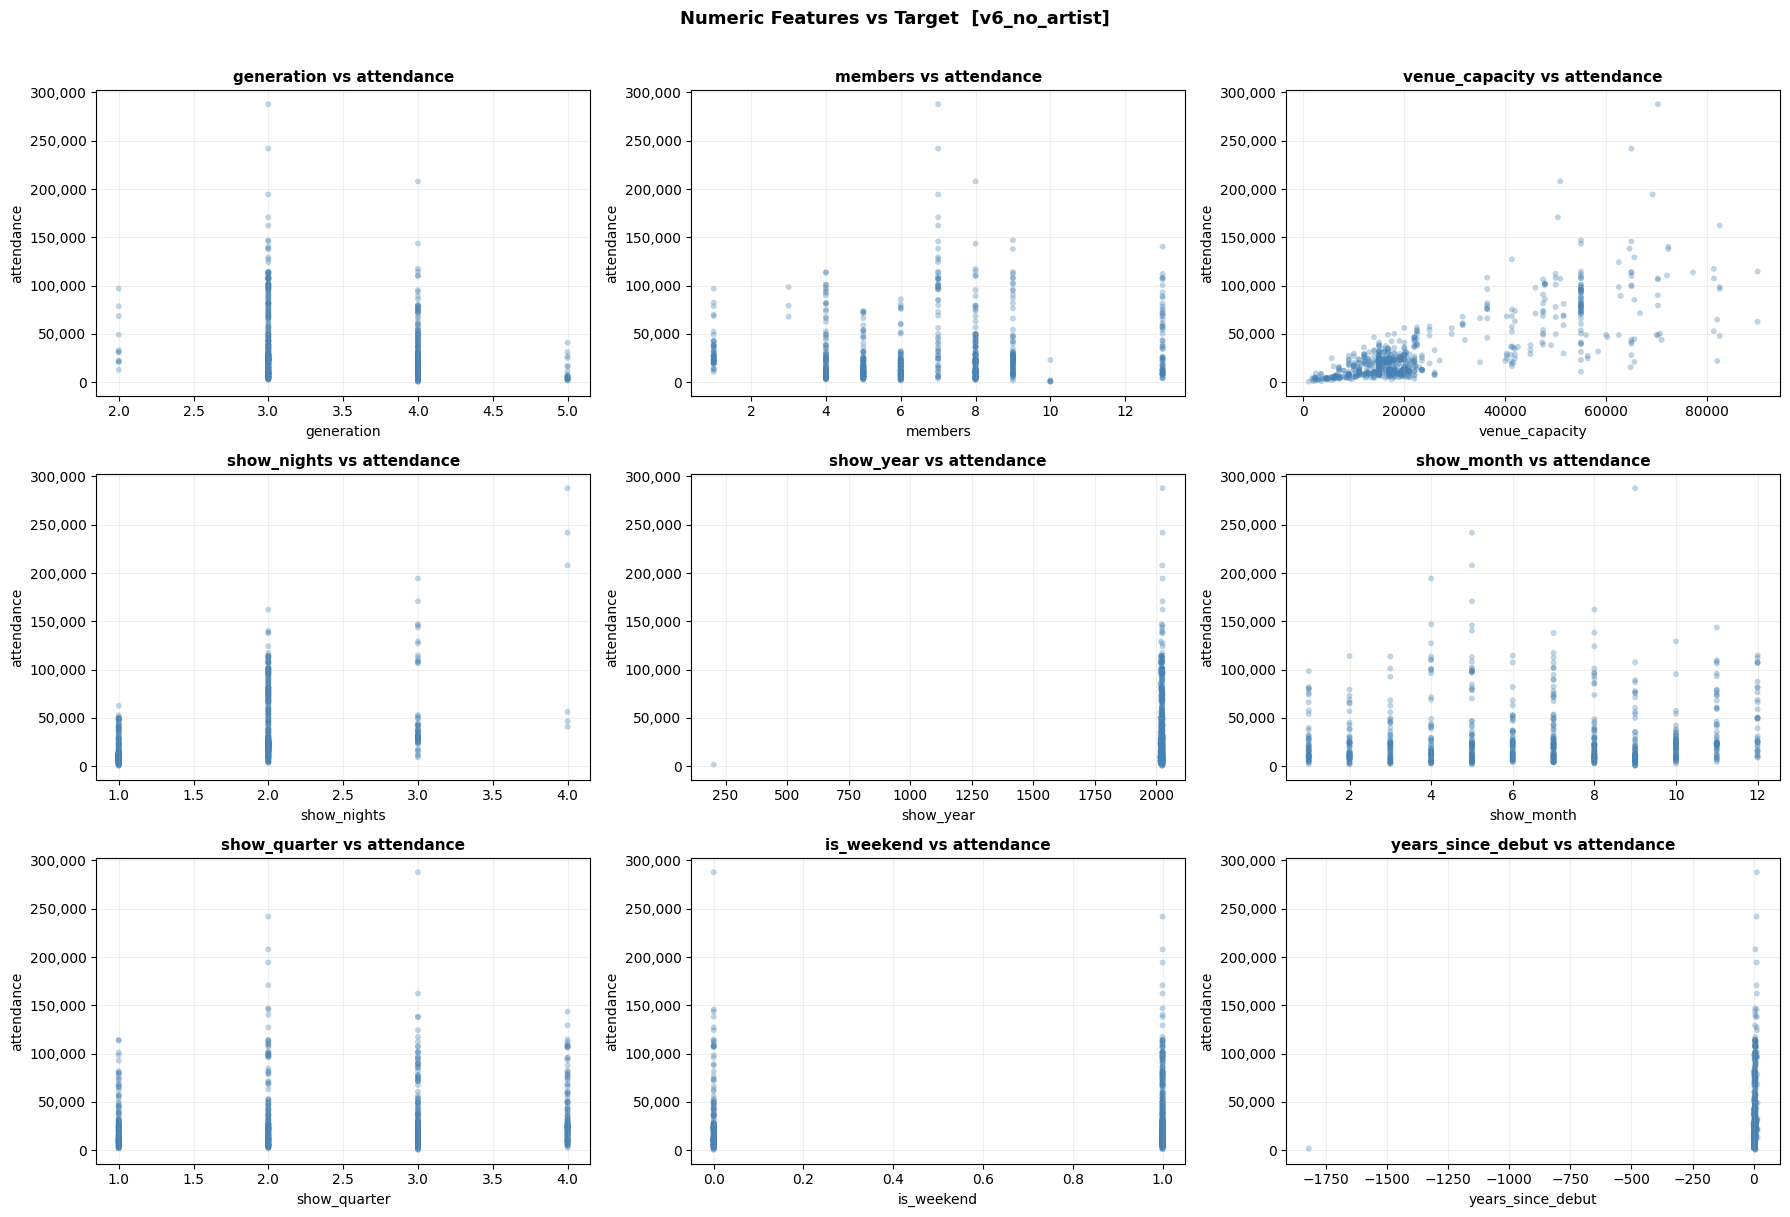


── 4. Categorical features vs target ─────────────────────────────────


e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


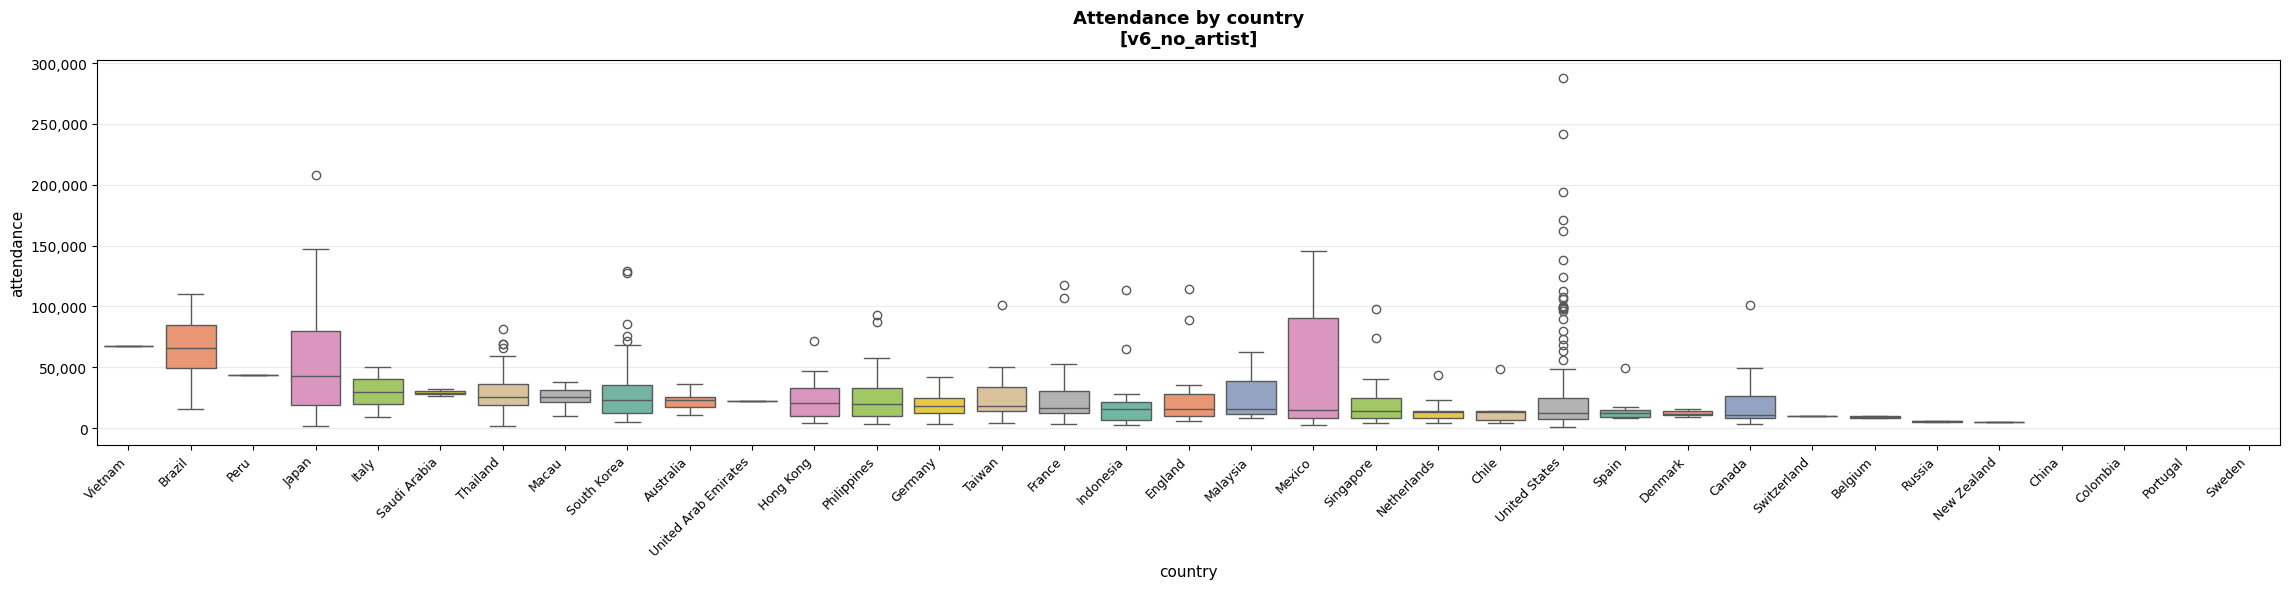

e:\code\tour-prediction\src\analysis\plots.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=column, y=target, order=order, palette=_CAT_PALETTE, ax=ax)


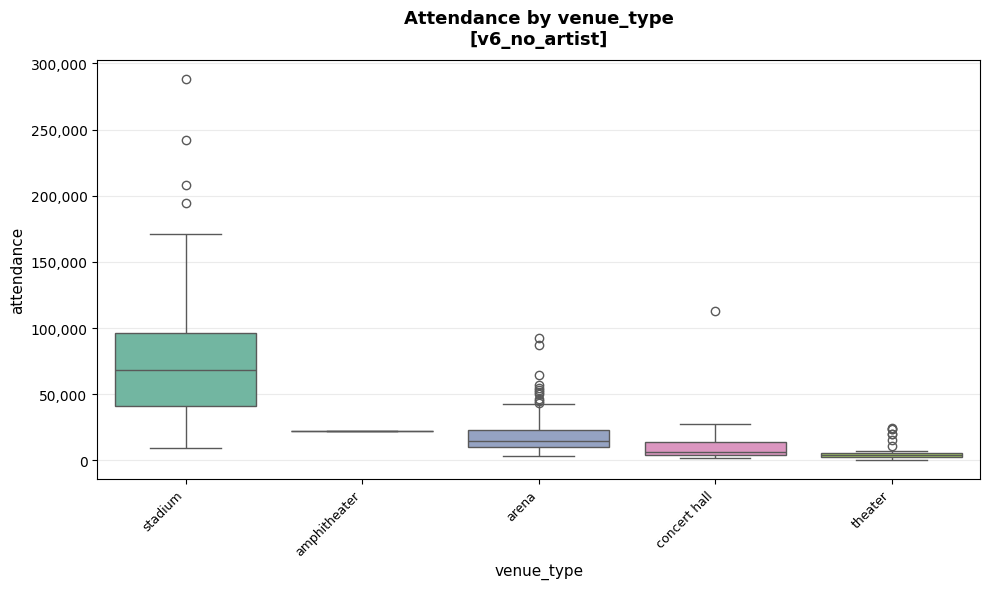


── 5. Attendance over time ───────────────────────────────────────────


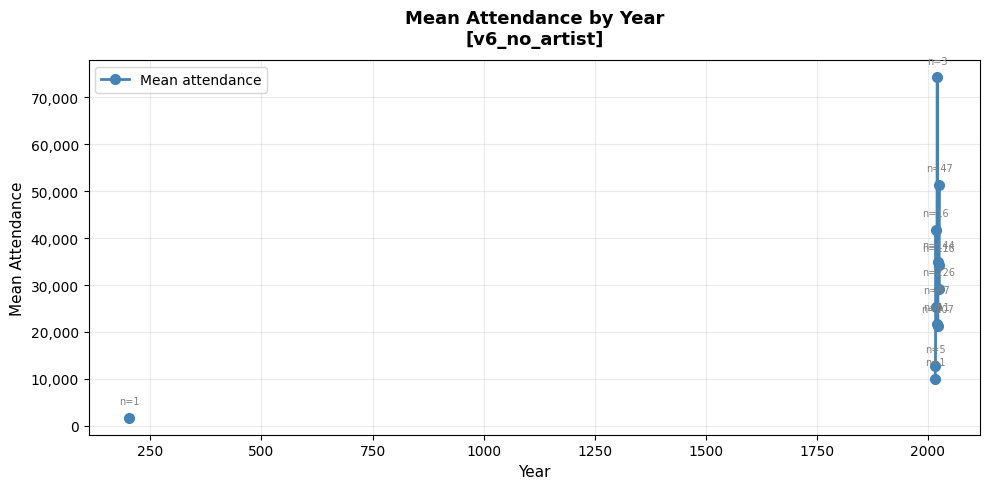


── 6. Correlation heatmap ────────────────────────────────────────────


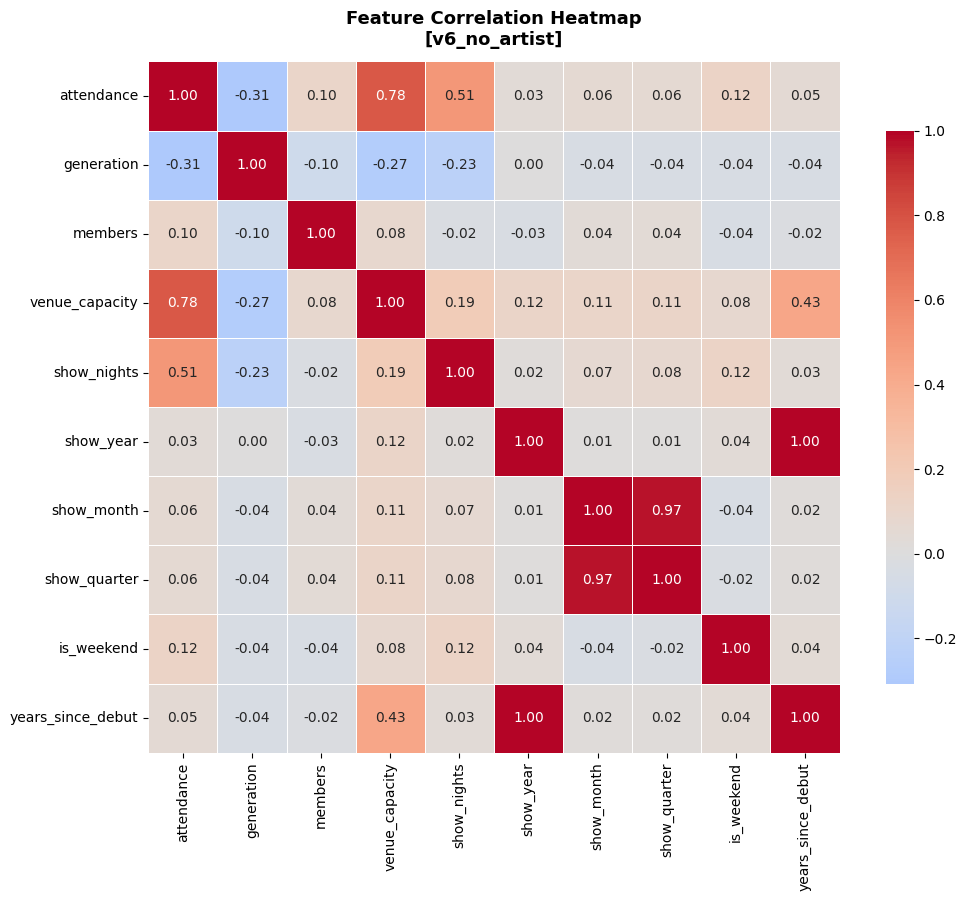


──────────────────────────────────────────────────────────────────────



In [3]:
for dataset_name, dataset_path in DATASETS.items():

    # ── Header ────────────────────────────────────────────────────────────────
    print()
    print("#" * 70)
    print(f"#  DATASET: {dataset_name}")
    print("#" * 70)

    df = pd.read_csv(dataset_path)

    # ── 1. Basic info ─────────────────────────────────────────────────────────
    print("\n── 1. Basic info " + "─" * 53)
    print_basic_info(df, dataset_name)
    print_missing_values(df)
    print_target_summary(df, target=TARGET)

    # ── 2. Target distribution ────────────────────────────────────────────────
    print("\n── 2. Target distribution " + "─" * 44)
    plot_target_distribution(df, dataset_name, target=TARGET)

    # ── 3. Numeric features vs target ─────────────────────────────────────────
    print("\n── 3. Numeric features vs target " + "─" * 37)
    plot_numeric_vs_target(df, dataset_name, target=TARGET)

    # ── 4. Categorical features vs target ─────────────────────────────────────
    print("\n── 4. Categorical features vs target " + "─" * 33)
    for cat_col in CAT_COLS:
        plot_attendance_by_category(df, dataset_name, cat_col, target=TARGET)

    # ── 5. Attendance over time ───────────────────────────────────────────────
    print("\n── 5. Attendance over time " + "─" * 43)
    plot_attendance_by_year(df, dataset_name, target=TARGET)

    # ── 6. Correlation heatmap ────────────────────────────────────────────────
    print("\n── 6. Correlation heatmap " + "─" * 44)
    plot_correlation_heatmap(df, dataset_name, target=TARGET)

    print("\n" + "─" * 70 + "\n")

## Part 2 — Post-Training Diagnostics

For each dataset × model combination:
- **Predicted vs Actual** — how well predictions track reality
- **Residuals** — where and how the model fails
- **Feature Importance** — what drives predictions (tree models only)


######################################################################
#  DIAGNOSTICS: v1_baseline
######################################################################

── Decision Tree ───────────────────────────────────────────────
  MAE=5,090  RMSE=8,582  R²=0.9112


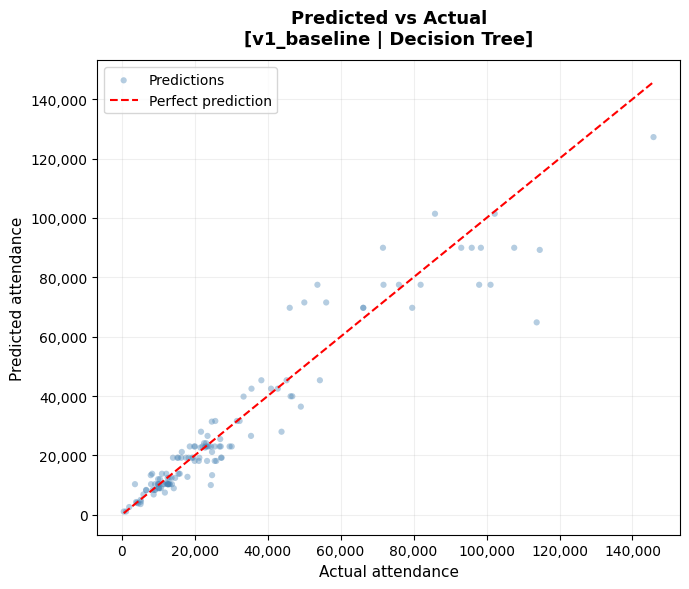

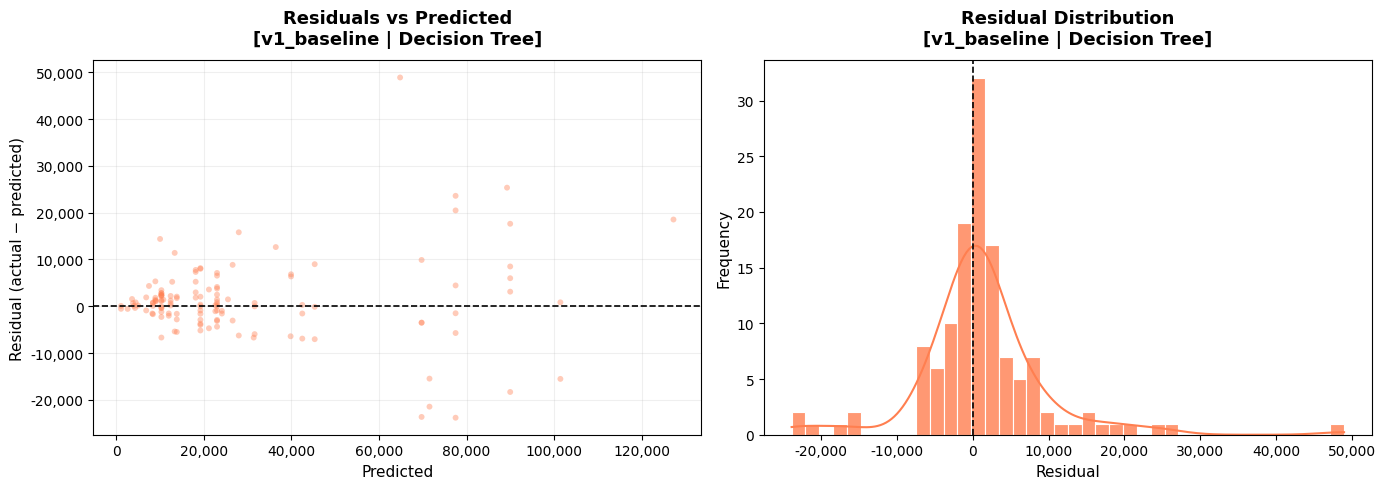

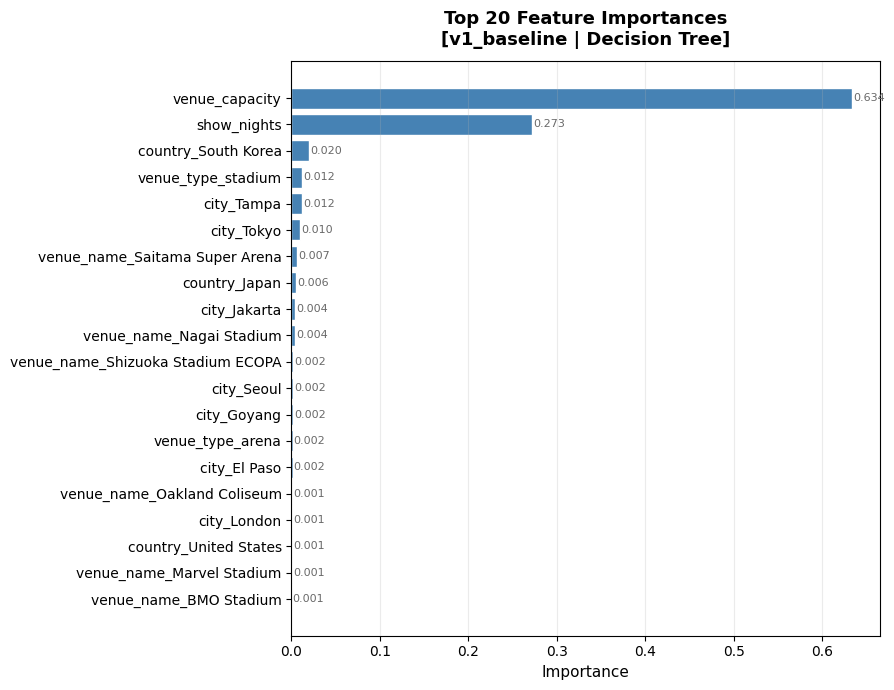


── Random Forest ───────────────────────────────────────────────
  MAE=4,655  RMSE=7,311  R²=0.9356


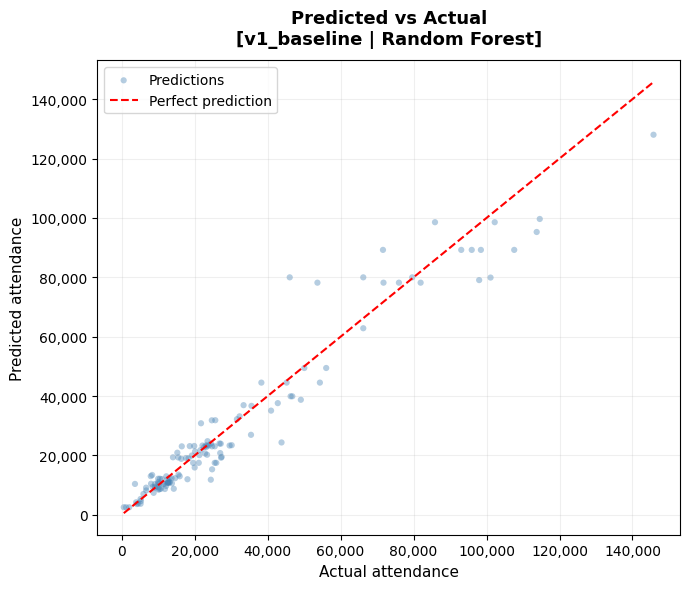

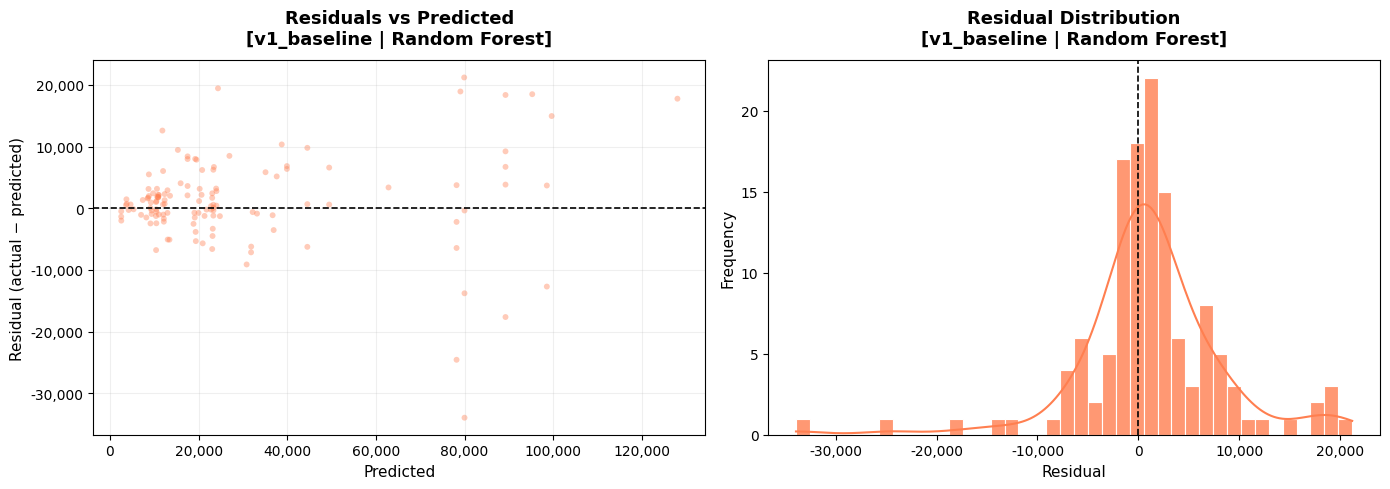

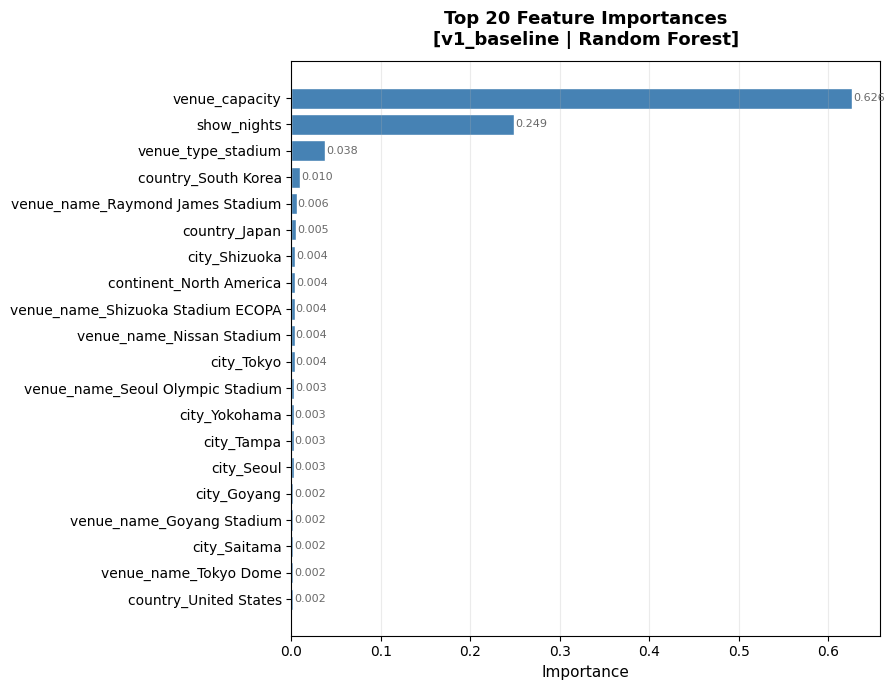


── MLP ─────────────────────────────────────────────────────────


e:\code\tour-prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  MAE=11,566  RMSE=17,870  R²=0.6150


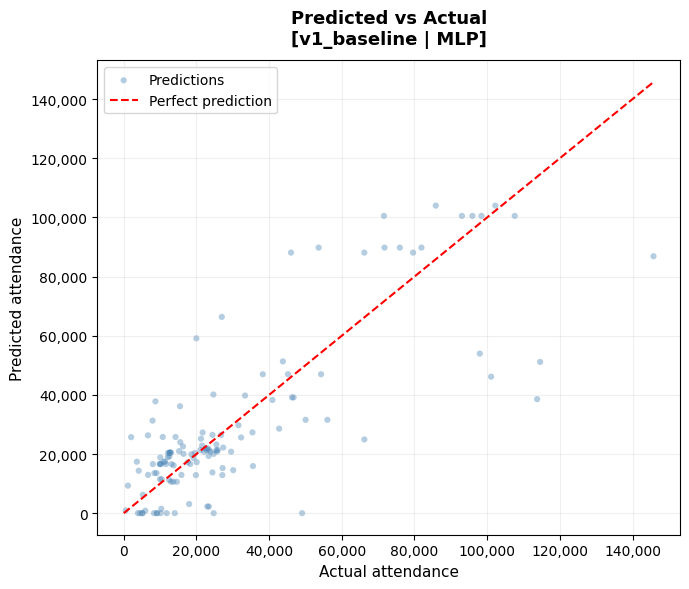

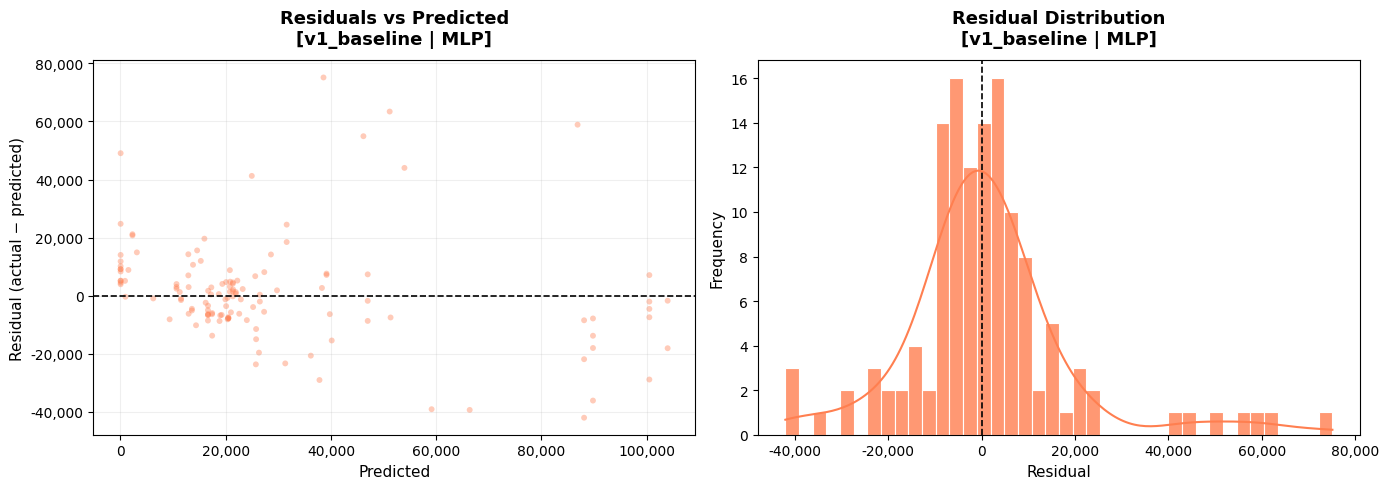


──────────────────────────────────────────────────────────────────────


######################################################################
#  DIAGNOSTICS: v2_artist
######################################################################

── Decision Tree ───────────────────────────────────────────────
  MAE=5,327  RMSE=9,063  R²=0.9010


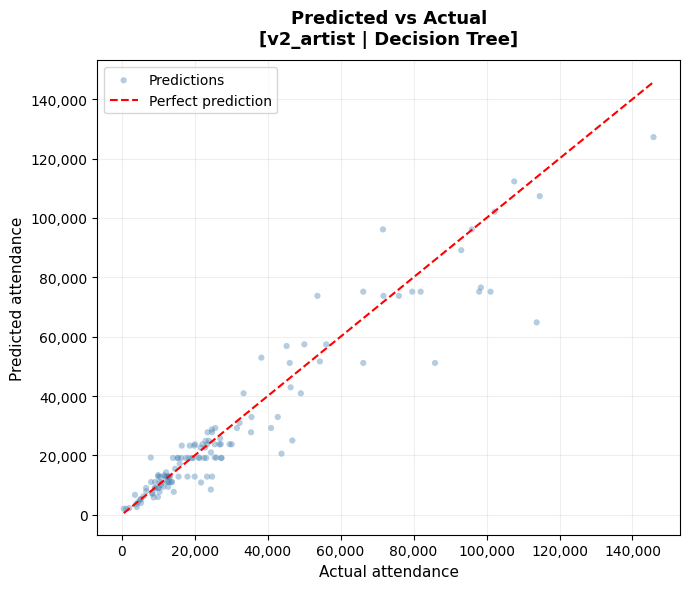

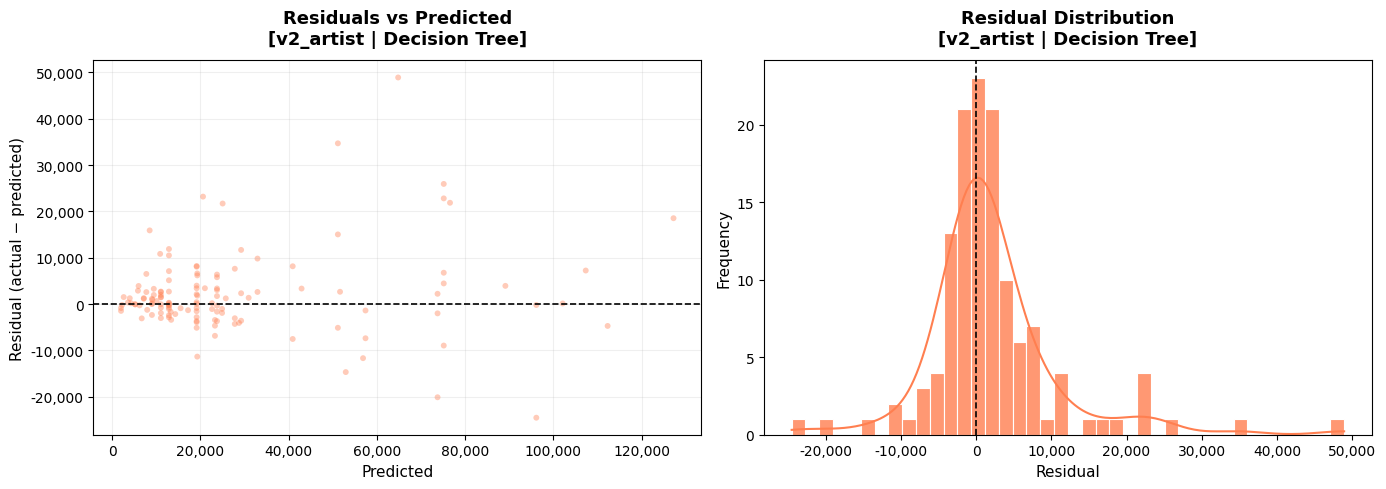

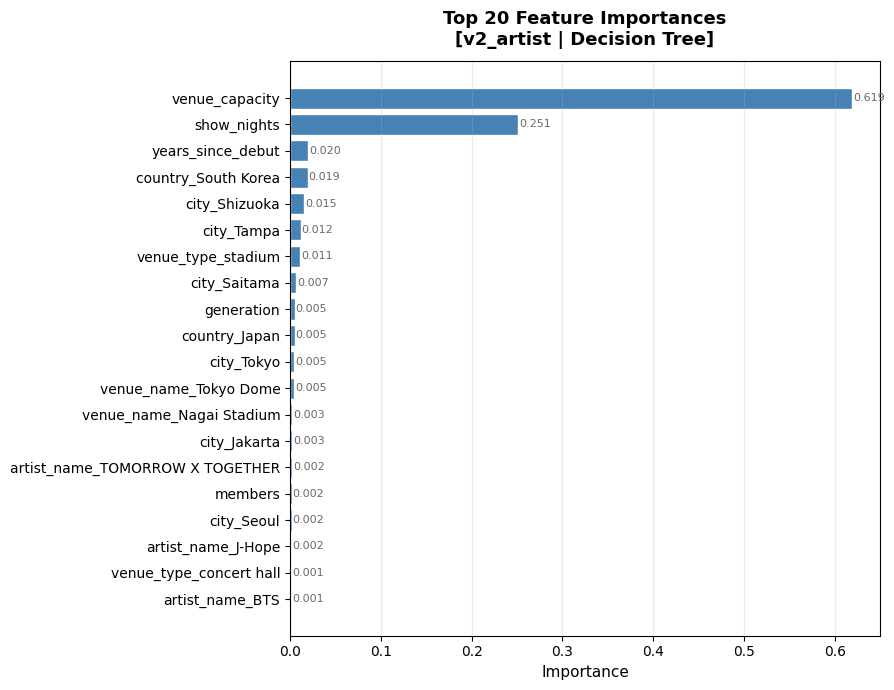


── Random Forest ───────────────────────────────────────────────
  MAE=4,120  RMSE=6,196  R²=0.9537


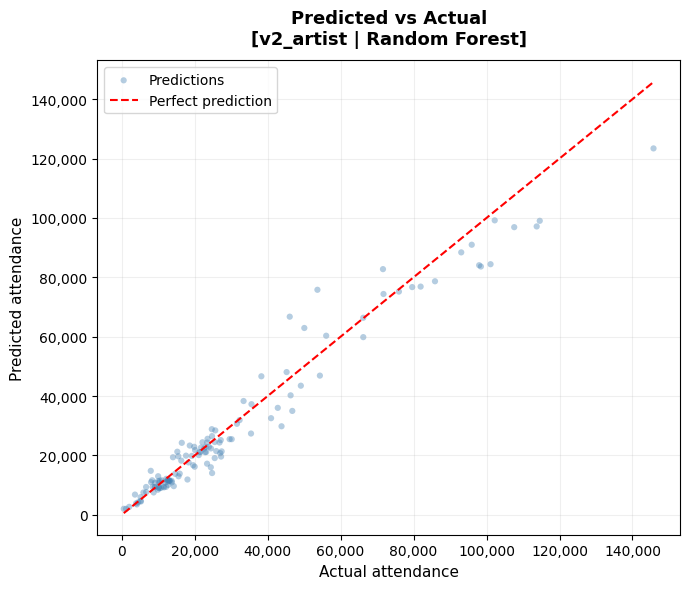

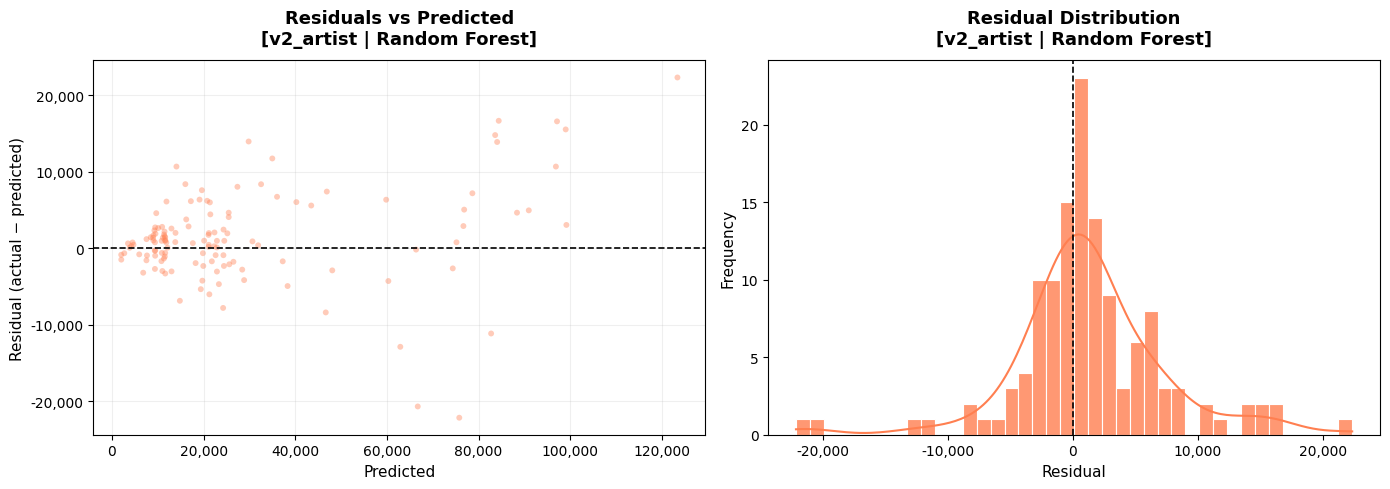

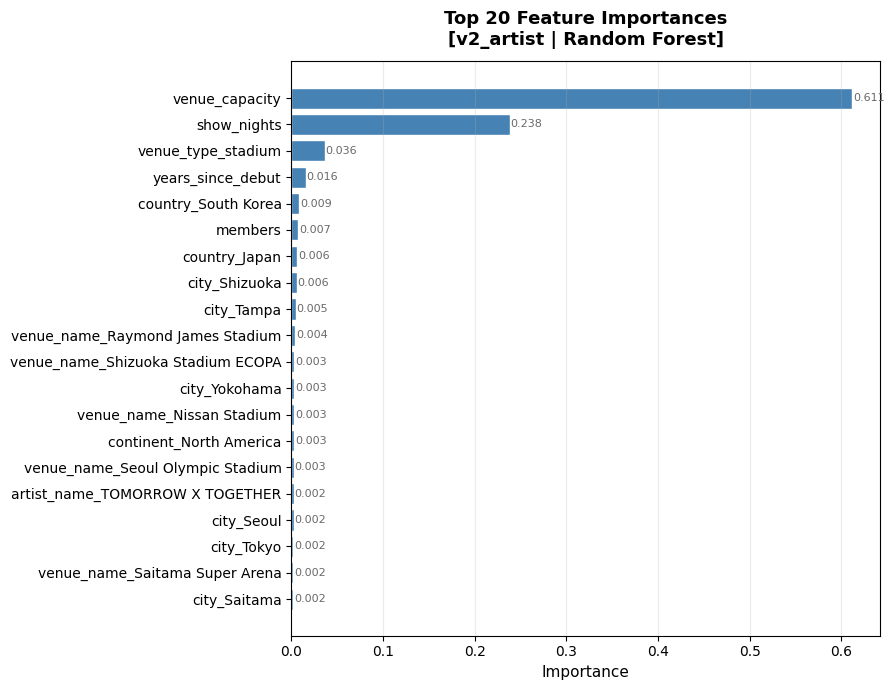


── MLP ─────────────────────────────────────────────────────────
  MAE=11,528  RMSE=17,068  R²=0.6488


e:\code\tour-prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


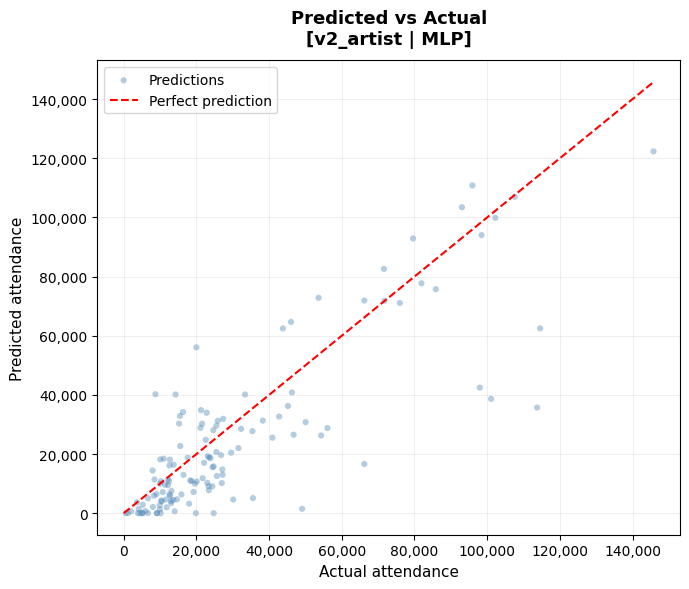

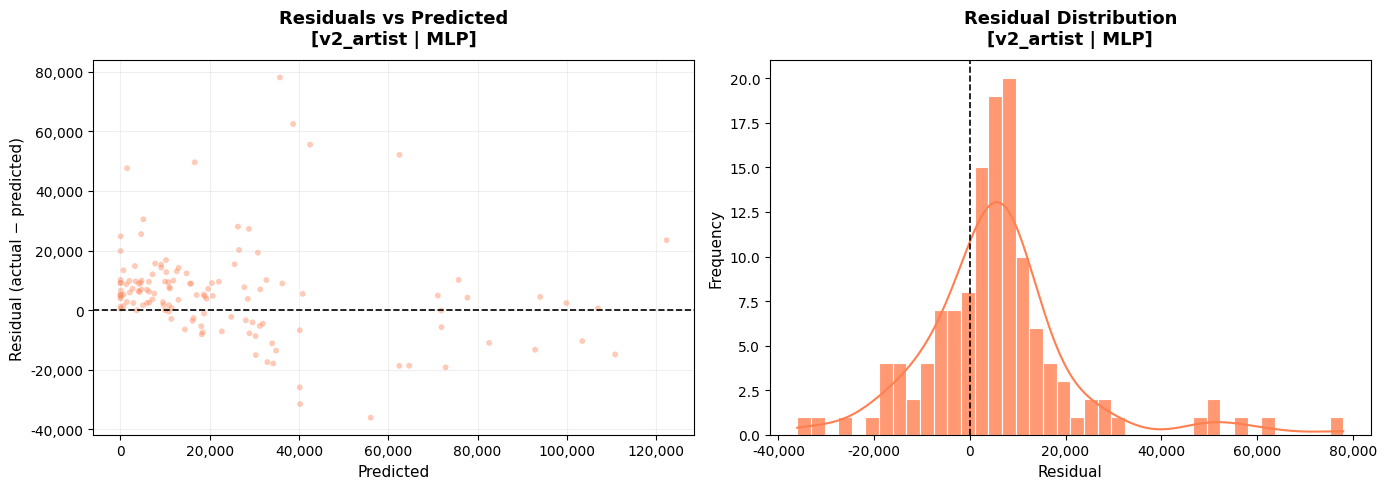


──────────────────────────────────────────────────────────────────────


######################################################################
#  DIAGNOSTICS: v3_artist_geo
######################################################################

── Decision Tree ───────────────────────────────────────────────
  MAE=5,537  RMSE=9,615  R²=0.8886


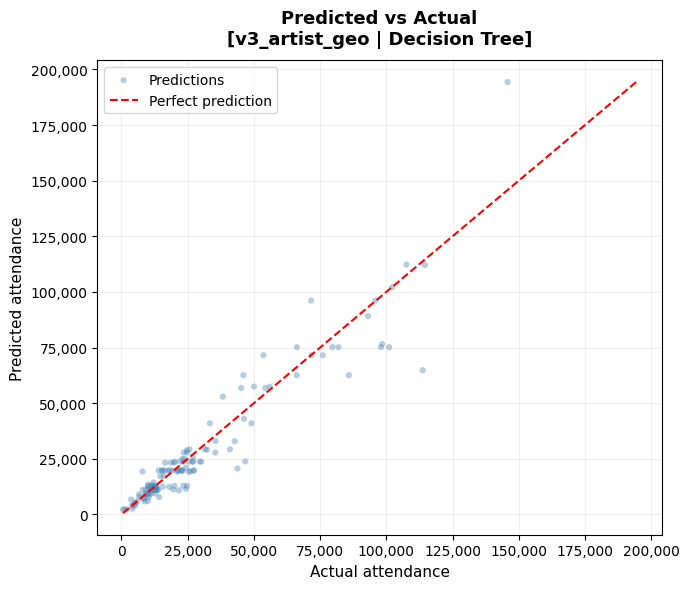

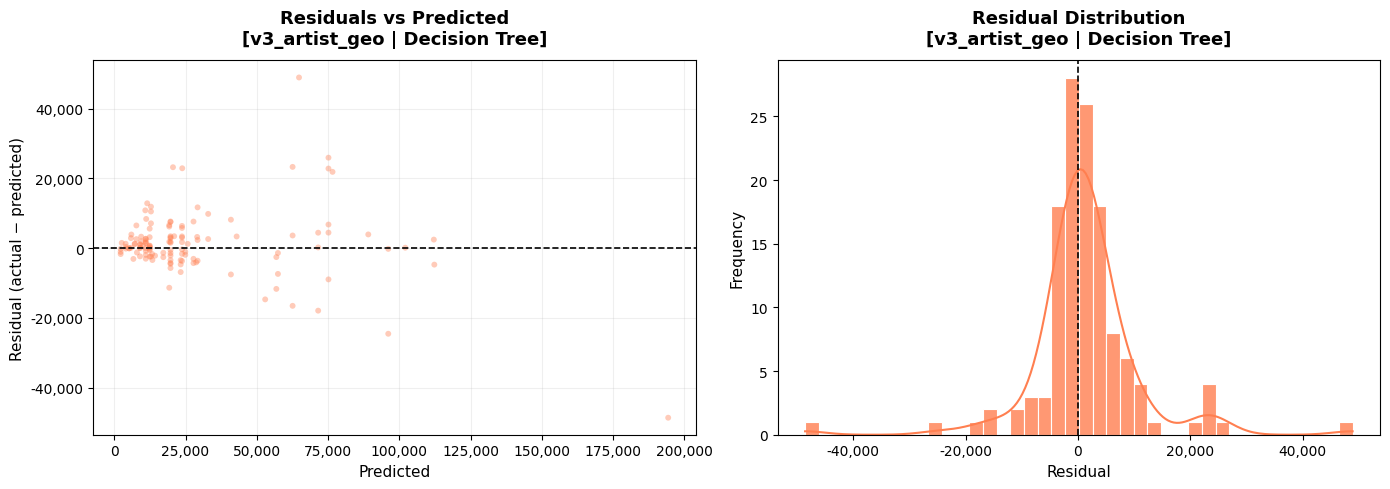

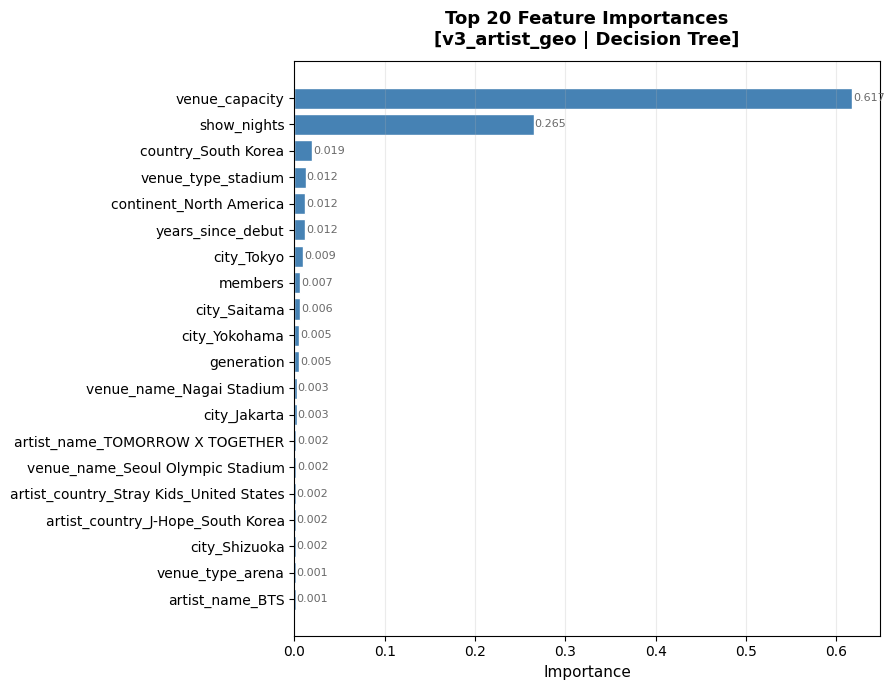


── Random Forest ───────────────────────────────────────────────
  MAE=4,145  RMSE=6,308  R²=0.9520


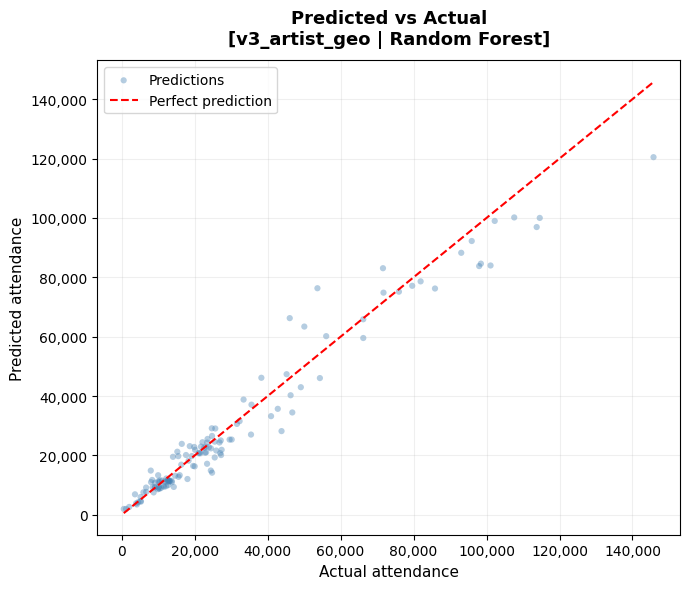

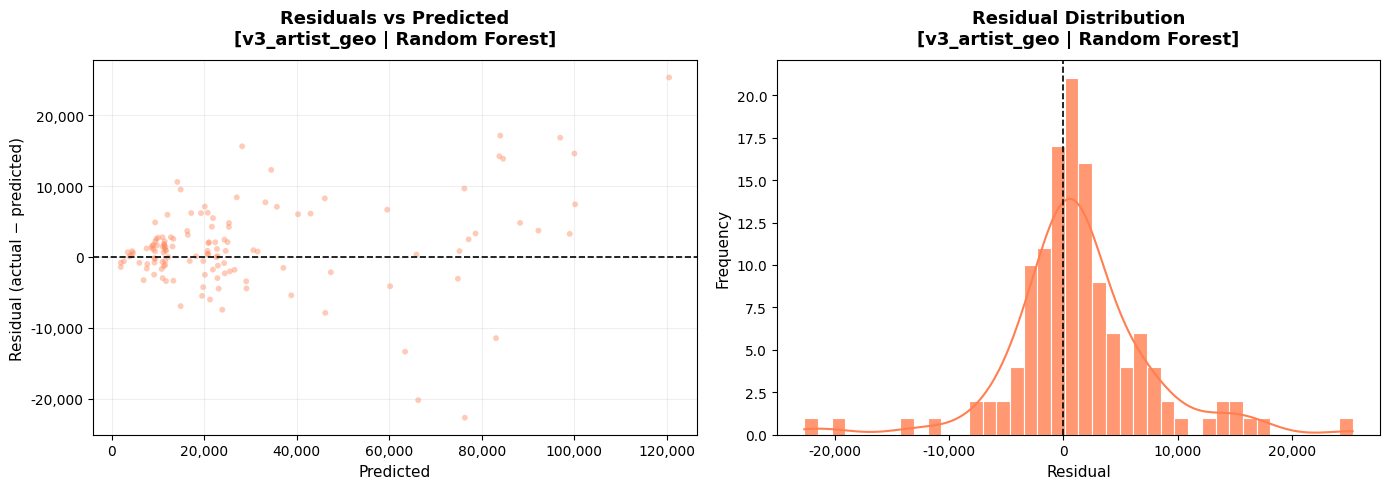

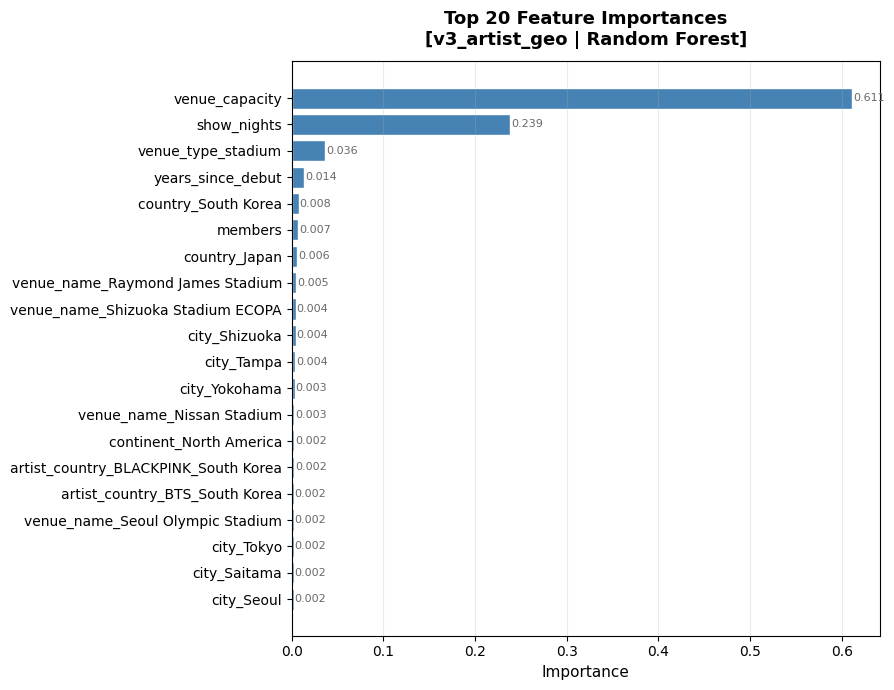


── MLP ─────────────────────────────────────────────────────────
  MAE=11,687  RMSE=19,521  R²=0.5406


e:\code\tour-prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


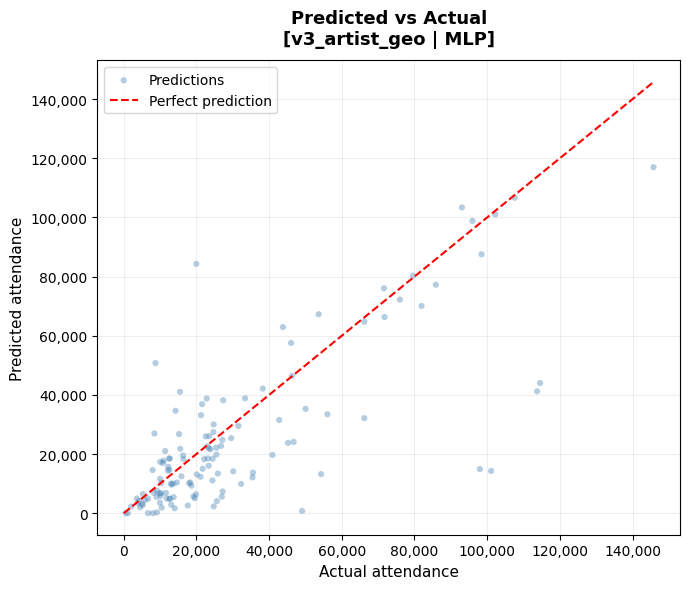

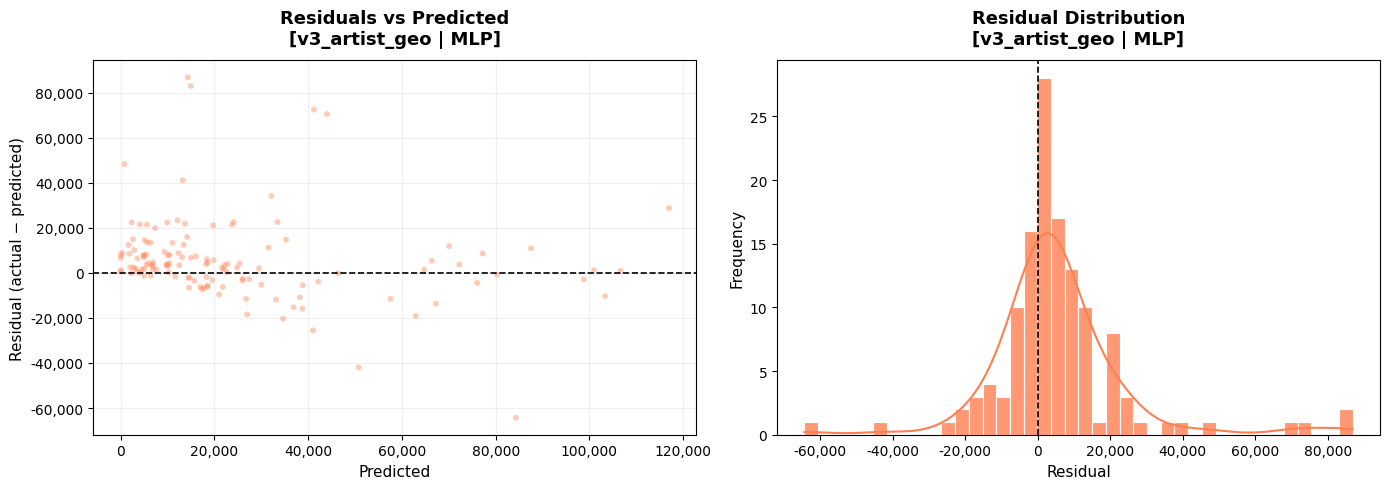


──────────────────────────────────────────────────────────────────────


######################################################################
#  DIAGNOSTICS: v4_artist_geo_time
######################################################################

── Decision Tree ───────────────────────────────────────────────
  MAE=5,613  RMSE=11,669  R²=0.8359


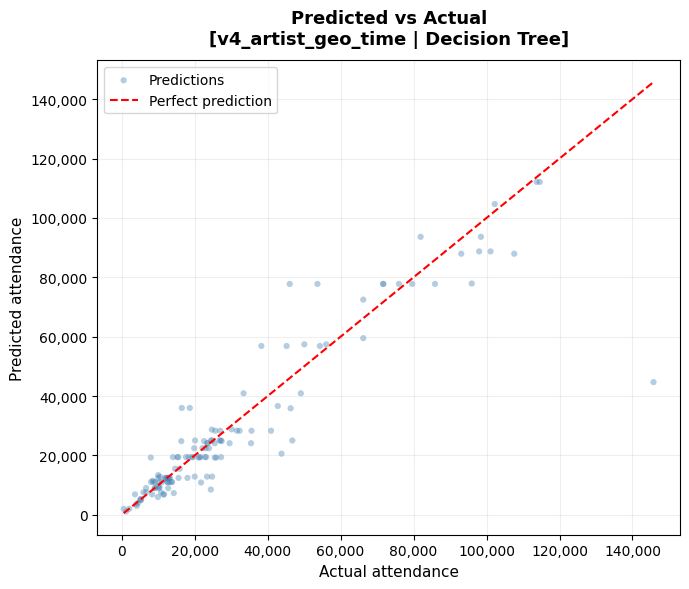

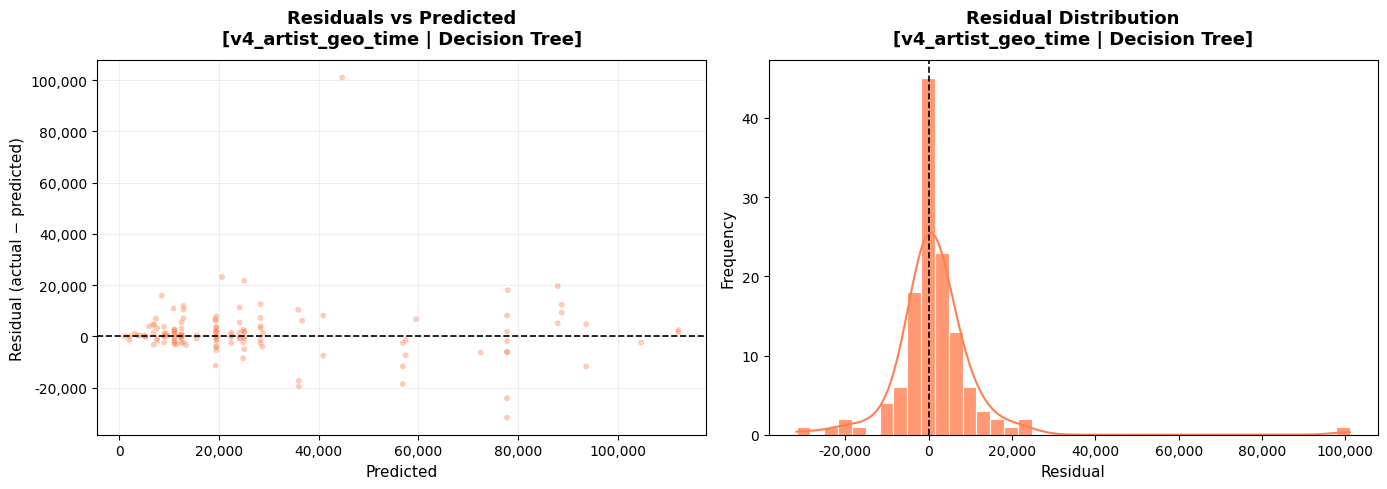

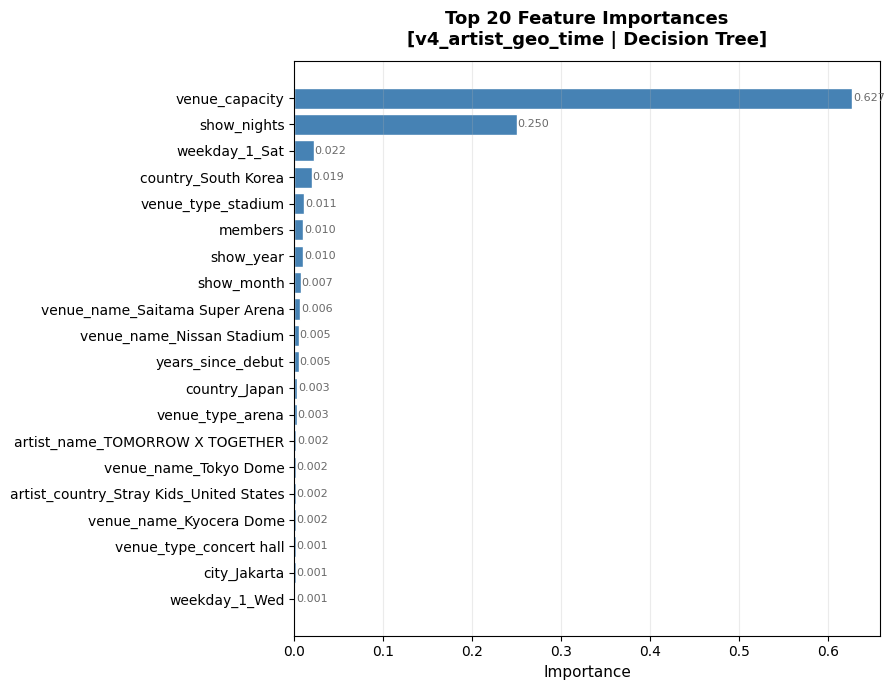


── Random Forest ───────────────────────────────────────────────
  MAE=4,187  RMSE=6,307  R²=0.9520


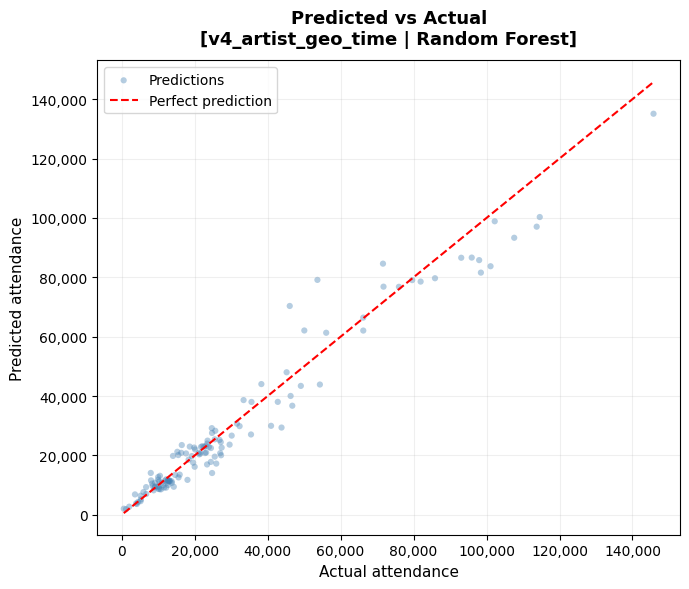

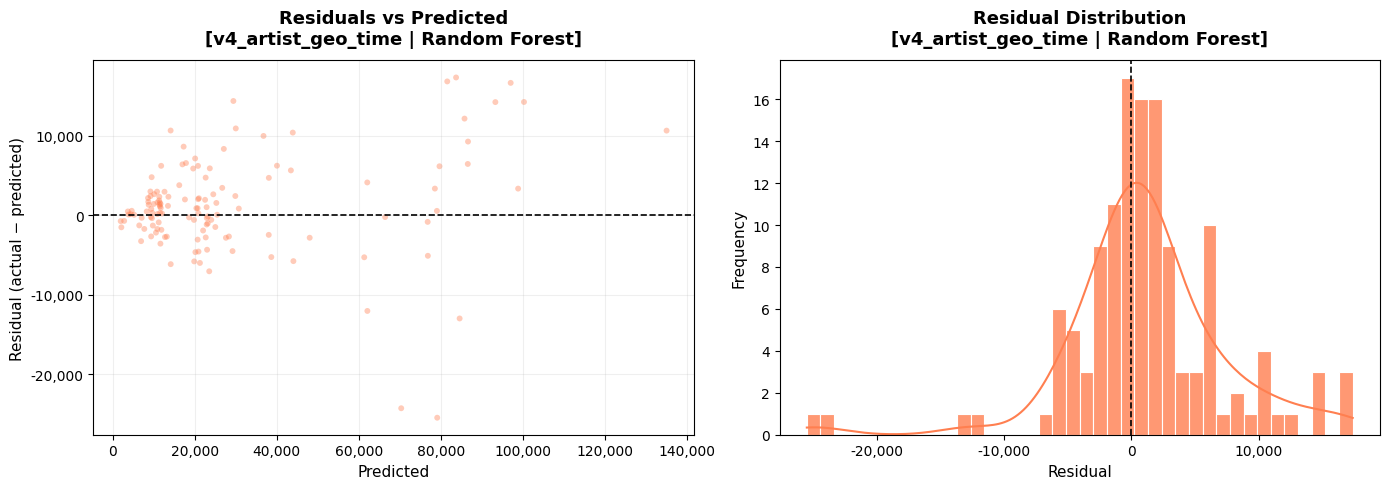

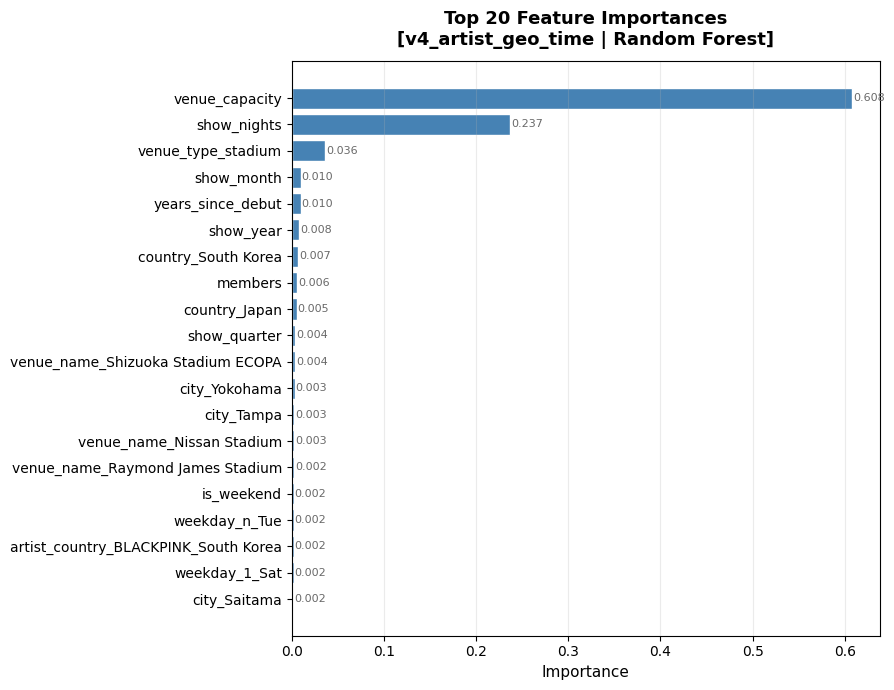


── MLP ─────────────────────────────────────────────────────────
  MAE=11,678  RMSE=18,839  R²=0.5722


e:\code\tour-prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


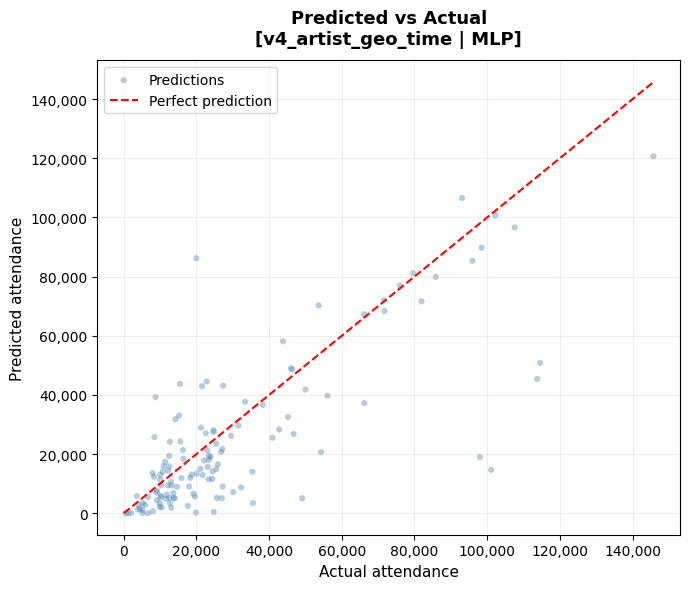

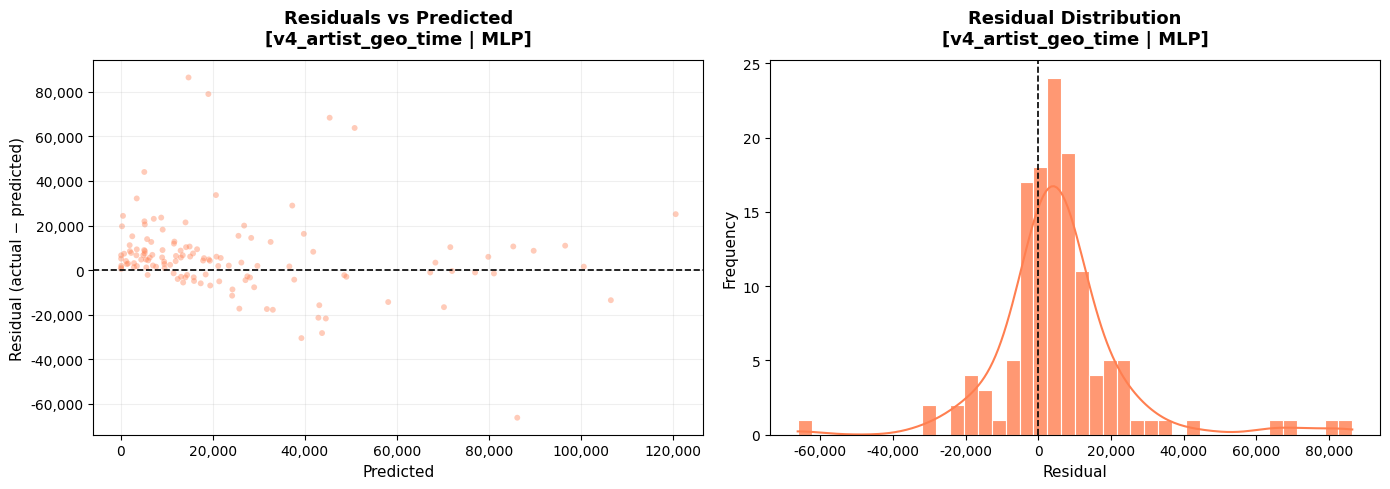


──────────────────────────────────────────────────────────────────────


######################################################################
#  DIAGNOSTICS: v5_full
######################################################################

── Decision Tree ───────────────────────────────────────────────
  MAE=5,754  RMSE=9,664  R²=0.8874


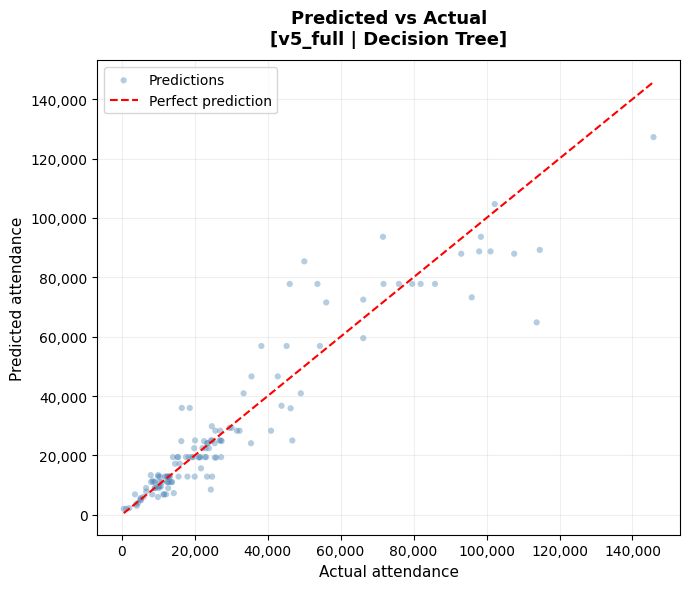

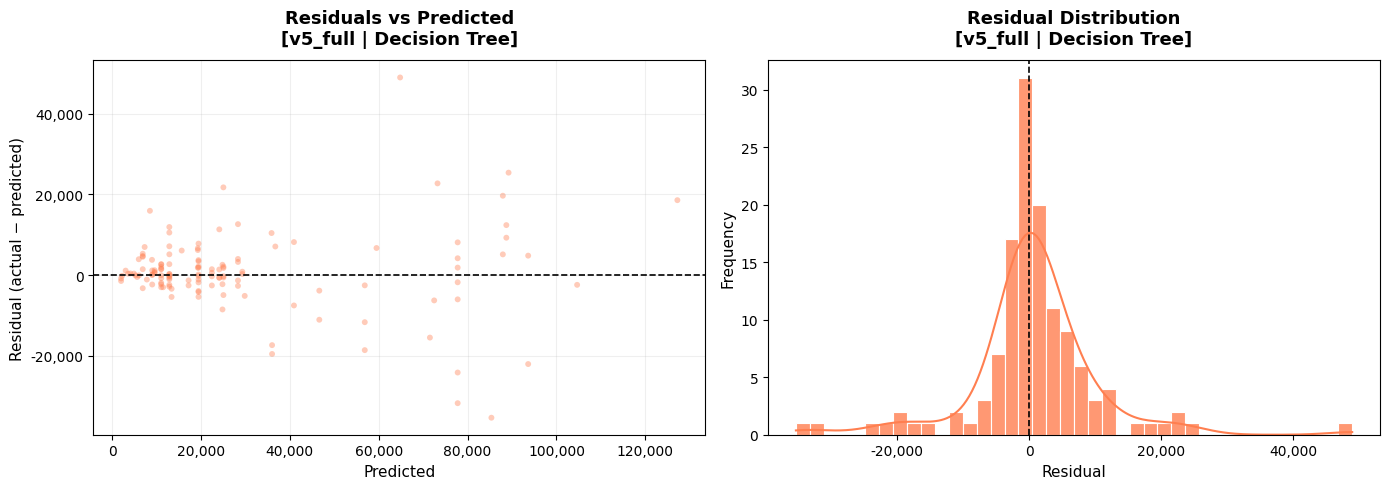

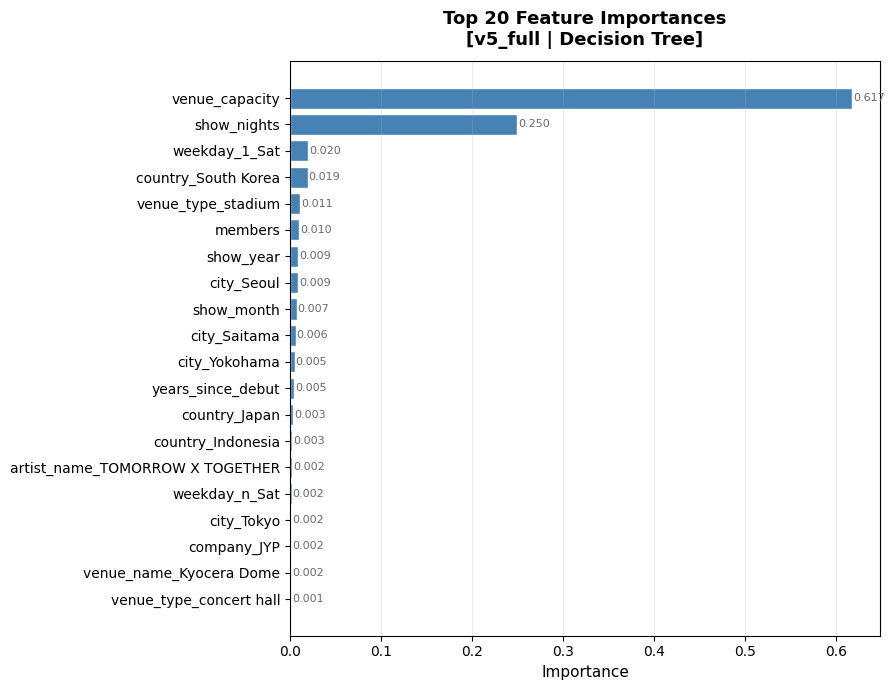


── Random Forest ───────────────────────────────────────────────
  MAE=4,167  RMSE=6,216  R²=0.9534


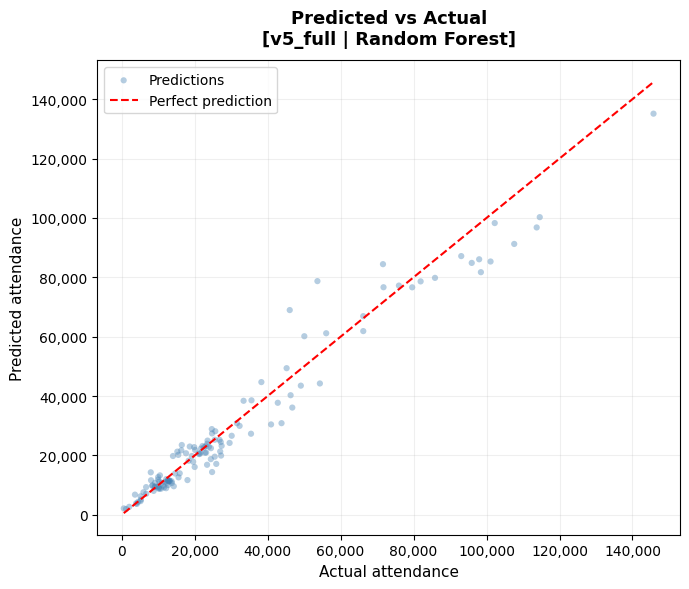

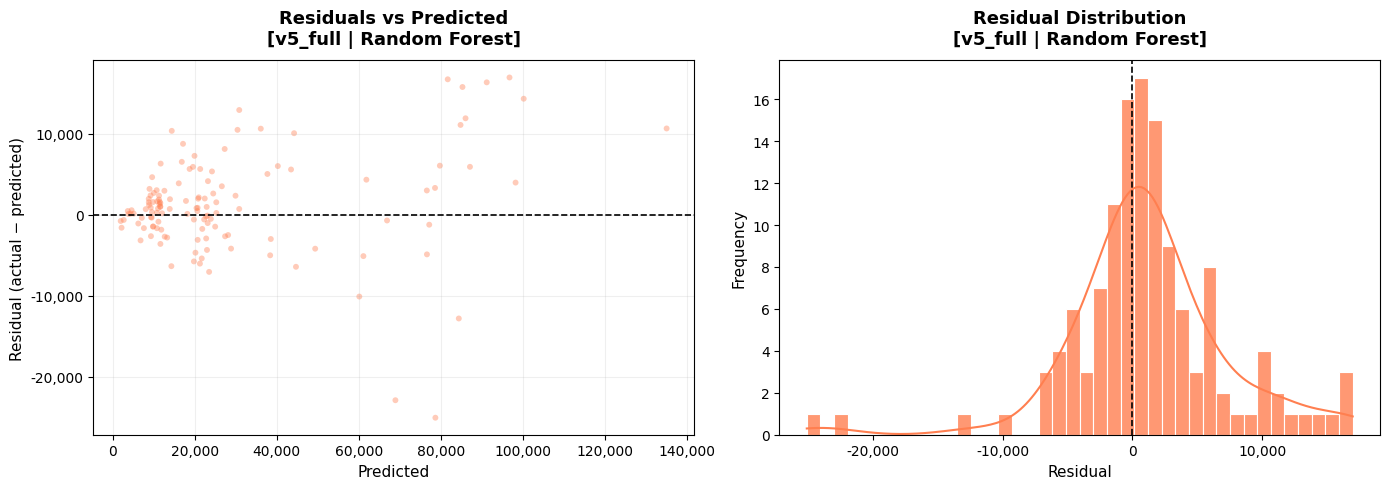

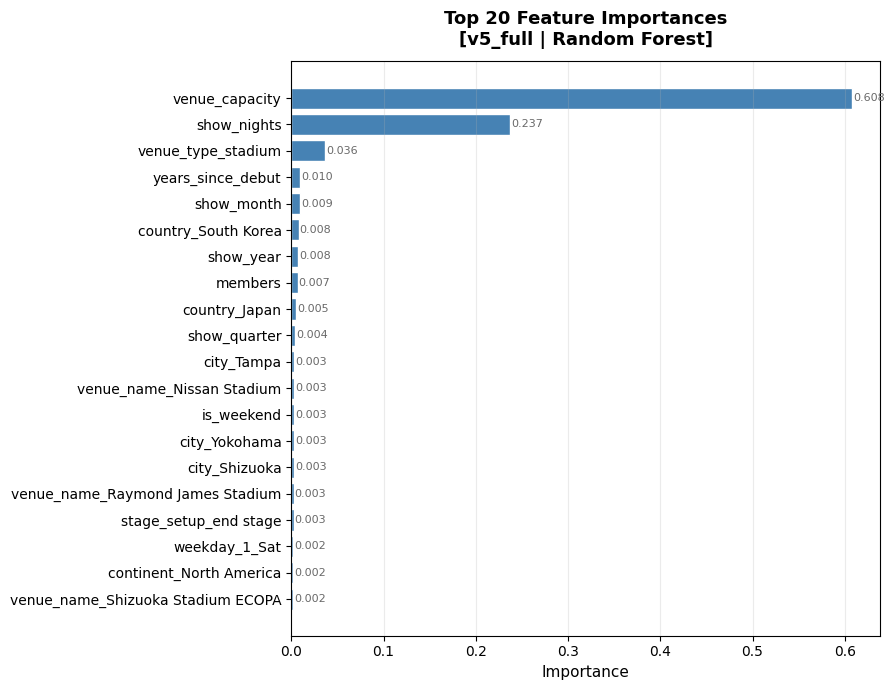


── MLP ─────────────────────────────────────────────────────────
  MAE=11,381  RMSE=16,626  R²=0.6668


e:\code\tour-prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


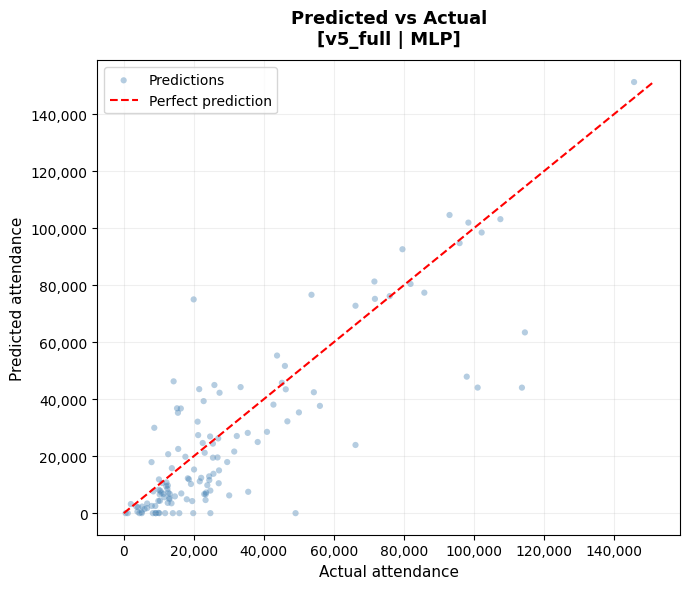

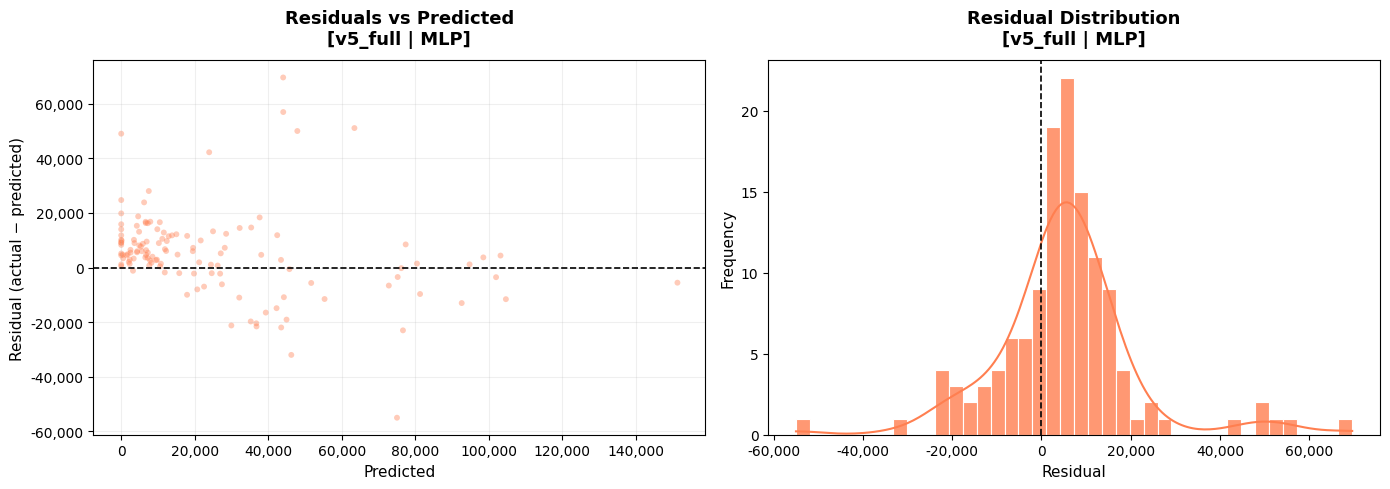


──────────────────────────────────────────────────────────────────────


######################################################################
#  DIAGNOSTICS: v6_no_artist
######################################################################

── Decision Tree ───────────────────────────────────────────────
  MAE=4,794  RMSE=7,961  R²=0.9236


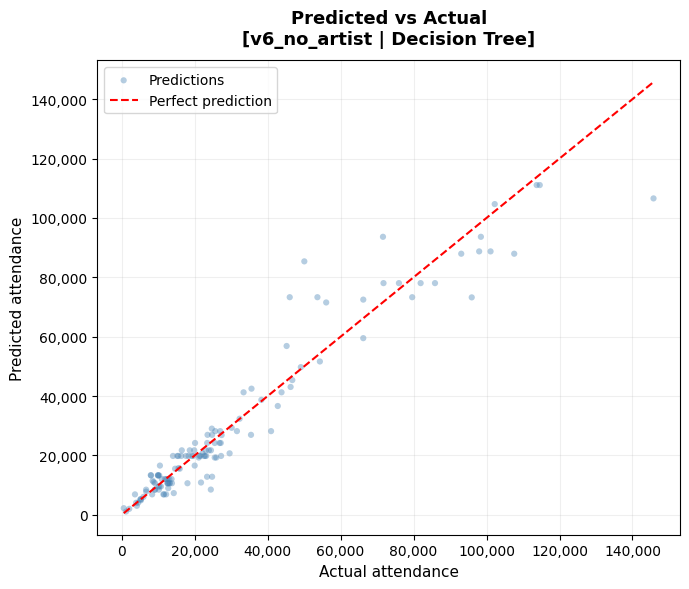

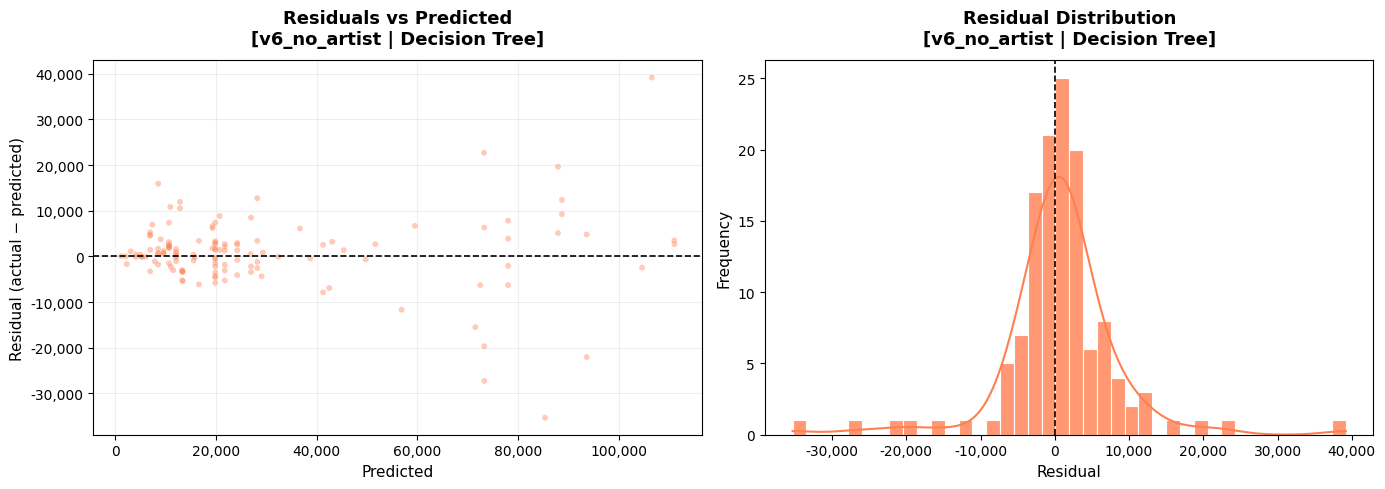

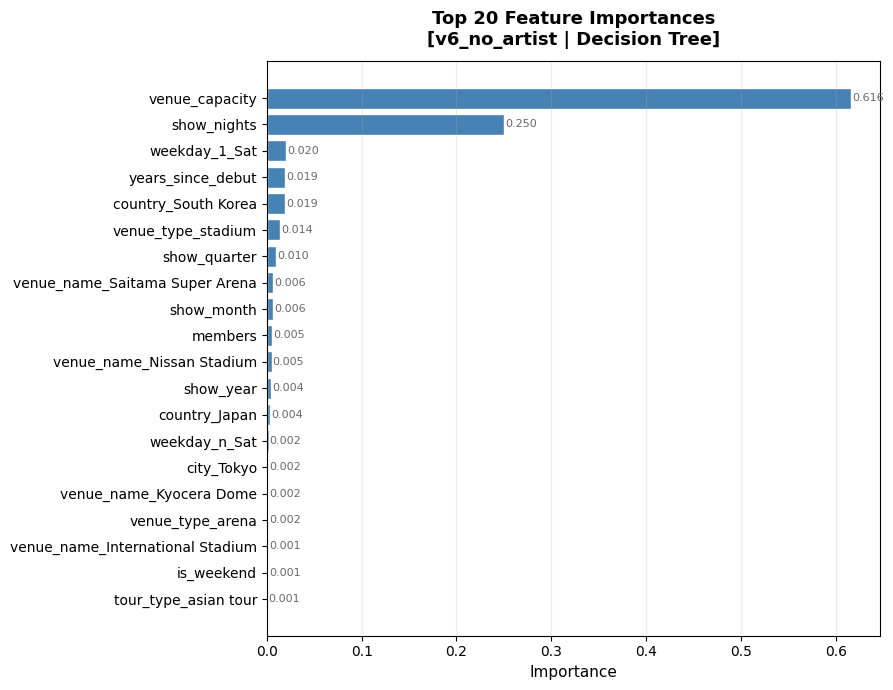


── Random Forest ───────────────────────────────────────────────
  MAE=4,279  RMSE=6,420  R²=0.9503


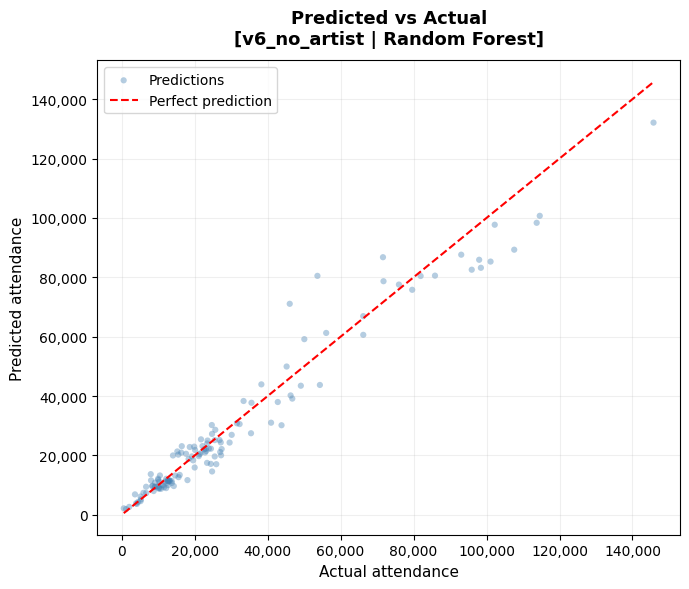

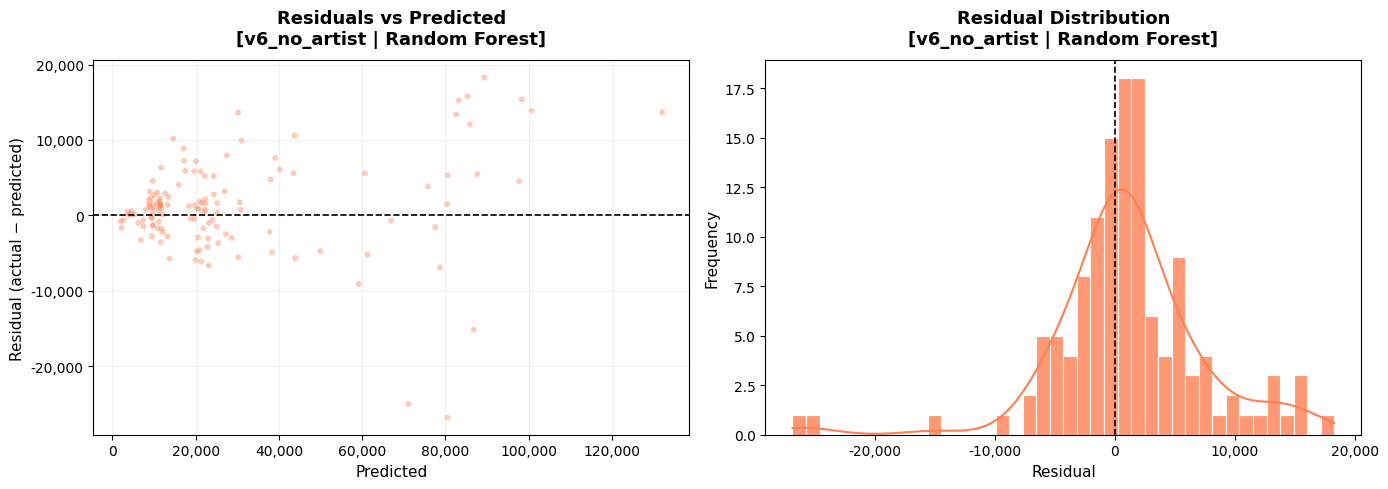

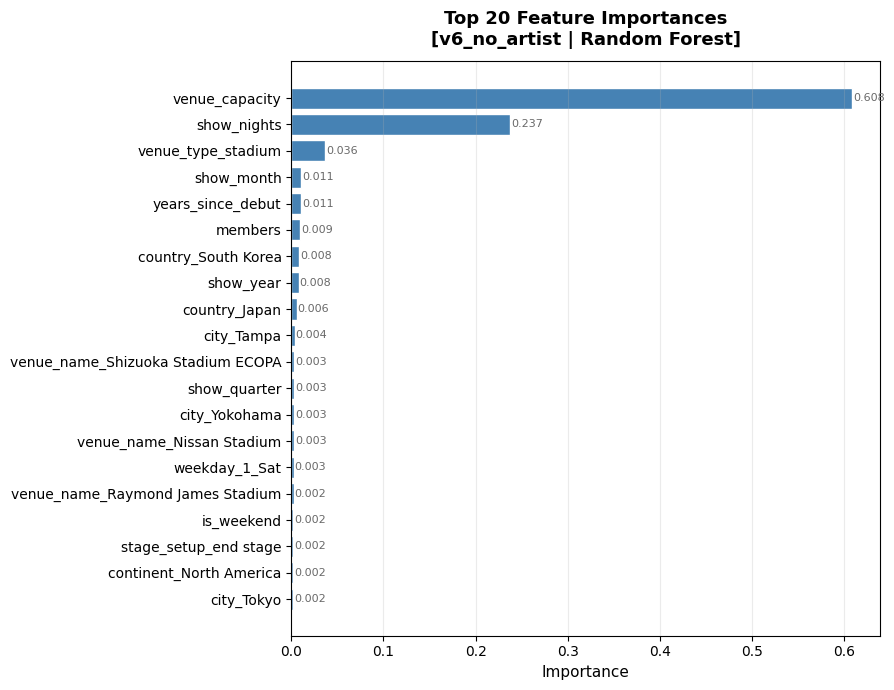


── MLP ─────────────────────────────────────────────────────────
  MAE=10,290  RMSE=15,334  R²=0.7165


e:\code\tour-prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


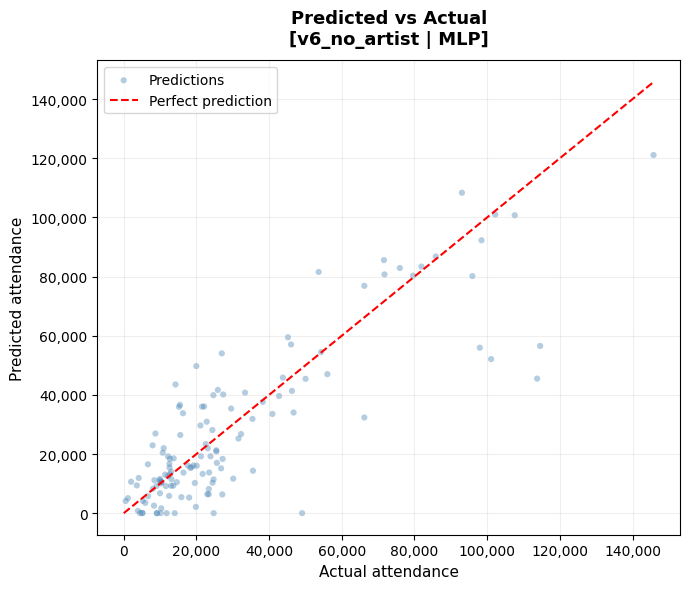

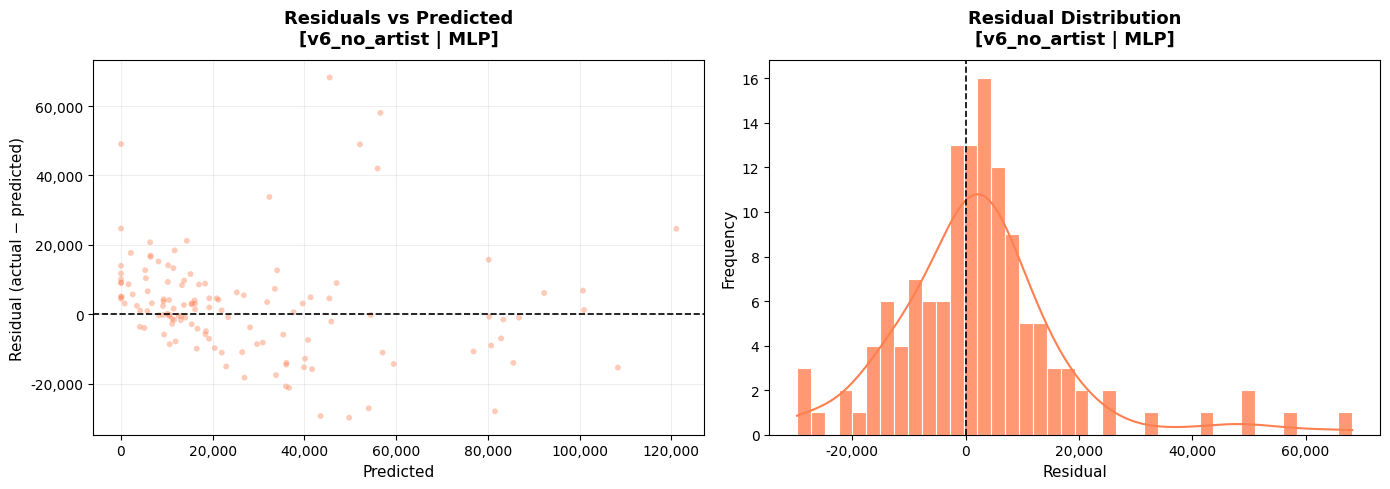


──────────────────────────────────────────────────────────────────────



In [4]:
for dataset_name, dataset_path in DATASETS.items():

    # ── Header ────────────────────────────────────────────────────────────────
    print()
    print("#" * 70)
    print(f"#  DIAGNOSTICS: {dataset_name}")
    print("#" * 70)

    # ── Prepare data (mirrors experiments.py exactly) ─────────────────────────
    df = pd.read_csv(dataset_path)

    if "reporting_status" in df.columns:
        df = df[df["reporting_status"] == "reported"]

    df = df.dropna(subset=[TARGET, "venue_capacity"])

    y = df[TARGET]
    X = df.drop(columns=[TARGET])

    cols_to_drop = [c for c in LEAKY_COLS if c in X.columns]
    X = X.drop(columns=cols_to_drop)

    X = pd.get_dummies(X, drop_first=True)
    feature_names = X.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # ── Train & diagnose each model ───────────────────────────────────────────
    models_dict = get_regression_models()

    for model_name, model in models_dict.items():
        print(f"\n── {model_name} " + "─" * (60 - len(model_name)))

        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        metrics = calculate_regression_metrics(y_test, y_pred)
        print(f"  MAE={metrics['MAE']:,.0f}  RMSE={metrics['RMSE']:,.0f}  R²={metrics['R2']:.4f}")

        plot_predicted_vs_actual(y_test, y_pred, model_name, dataset_name, target=TARGET)
        plot_residuals(y_test, y_pred, model_name, dataset_name)

        # Feature importance — only for tree-based models
        if hasattr(model, "feature_importances_"):
            plot_feature_importance(
                feature_names,
                model.feature_importances_,
                model_name,
                dataset_name,
                top_n=20,
            )

    print("\n" + "─" * 70 + "\n")